# Visualizing Graph Construction


**To analyse:**

> The SOTA paper uses QTAIM Bond Critical Points as bond nodes.  
> But does QTAIM always find a BCP for every real covalent bond?  
> And how does this affect the GNN's ability to learn molecular properties?

**outline:**
1. **PKL file** — what columns exist, what types, pick a molecule
2. **PKL inspection** — atom list, real bonds, QTAIM bonds, scalar/atom/bond features
3. **JSON inspection** — ELF attractor ordering, verify index alignment
4. **Standard molecular graph** — ground truth from `molecule_graph.edges()`
5. **ELF attractor graph** — from JSON, all real bonds covered
6. **SOTA QTAIM graph** — from `bonds` column, what is missing and why
7. **Are missing bonds real?** — check molecule 2 (non-aromatic) to confirm
8. **Side-by-side comparison** — all three graphs together


##1) Setup: imports, paths, load PKL

In [1]:
import json, ast, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io, torch

ATOM_COLOR = {"C":"#2C2C2A","N":"#1E5FA5","O":"#C94F2A","H":"#9E9C96","F":"#1D9E75"}
BOND_COLOR  = "#C97B1A"
print("Imports OK")


Imports OK


In [2]:
BASE      = "/lustre/fsn1/projects/rech/ihj/urb54jd"
PKL_TRAIN = f"{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/train_43k.pkl"
PKL_VAL   = f"{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/val_43k.pkl"
PKL_TEST  = f"{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/test_43k.pkl"
ELF_CSV   = f"{BASE}/gnn/control_and_critical_points_GNNs/data/qm9_43k_clean_with_val.csv"
JSON_DIR  = f"{BASE}/gnn/control_and_critical_points_GNNs/data/criticalpoints_jsonfiles"
print("Paths set")


Paths set


In [3]:
print("Loading PKL...")
sota_df = pd.concat([pd.read_pickle(PKL_TRAIN),
                     pd.read_pickle(PKL_VAL),
                     pd.read_pickle(PKL_TEST)], ignore_index=True)
sota_df["gdb_num"] = sota_df["names"].str.extract(r"gdb_(\d+)\.xyz").astype(int)
elf_df  = pd.read_csv(ELF_CSV)
print(f"SOTA PKL: {len(sota_df)} rows")

# All columns in the PKL
print(f"Total columns: {len(sota_df.columns)}")
print()
for c in sota_df.columns:
    sample = sota_df[c].iloc[0]
    print(f"  {c:<45}  {type(sample).__name__}")


Loading PKL...
SOTA PKL: 43476 rows
Total columns: 63

  molecule                                       Molecule
  molecule_graph                                 MoleculeGraph
  ids                                            int64
  names                                          str
  bonds                                          list
  extra_feat_atom_Lagrangian_K                   ndarray
  extra_feat_atom_Hamiltonian_K                  ndarray
  extra_feat_atom_e_density                      ndarray
  extra_feat_atom_lap_e_density                  ndarray
  extra_feat_atom_e_loc_func                     ndarray
  extra_feat_atom_ave_loc_ion_E                  ndarray
  extra_feat_atom_delta_g_promolecular           ndarray
  extra_feat_atom_delta_g_hirsh                  ndarray
  extra_feat_atom_esp_nuc                        ndarray
  extra_feat_atom_esp_e                          ndarray
  extra_feat_atom_esp_total                      ndarray
  extra_feat_atom_grad_norm        

In [4]:
def _parse_bonds(raw):
    s = str(raw).strip()
    if s.startswith("[["): s = s[1:-1]
    try:    return [(int(a), int(b)) for a,b in ast.literal_eval(s)]
    except: return []

def _parse_array(raw):
    s = str(raw).strip()
    if s.startswith("[[") and s.endswith("]]"): s = s[1:-1]
    try:    return np.array(ast.literal_eval(s), dtype=float)
    except: return np.array([])

BOND_QTAIM_COLS = [
    "extra_feat_bond_Hamiltonian_K","extra_feat_bond_e_density",
    "extra_feat_bond_lap_e_density","extra_feat_bond_e_loc_func",
    "extra_feat_bond_ave_loc_ion_E","extra_feat_bond_delta_g_promolecular",
    "extra_feat_bond_delta_g_hirsh","extra_feat_bond_esp_nuc",
    "extra_feat_bond_esp_e","extra_feat_bond_esp_total",
    "extra_feat_bond_grad_norm","extra_feat_bond_lap_norm",
    "extra_feat_bond_eig_hess","extra_feat_bond_det_hessian",
    "extra_feat_bond_ellip_e_dens","extra_feat_bond_eta",
    "extra_feat_bond_energy_density","extra_feat_bond_lol",
    "extra_feat_bond_Lagrangian_K",
]

ATOM_COLOR = {"C":"#2C2C2A","N":"#1E5FA5","O":"#C94F2A","H":"#9E9C96","F":"#1D9E75"}
CP_BOND_C  = "#C97B1A"   # bonding attractor — orange diamond
CP_LONE_C  = "#7B1FA2"   # lone-pair attractor — purple diamond
CP_CORE_C  = "#888888"   # core attractor — grey triangle

IMG_SIZE = 600   # pixels for the molecule image

def get_atom_pixel_coords(smiles, n_atoms, img_size=IMG_SIZE):
    """
    Get pixel coordinates of each atom as drawn by RDKit MolToImage.
    Uses rdMolDraw2D to get the EXACT same positions as the PNG rendering.
    Returns: pos dict {atom_idx: (x_pixel, y_pixel)}, PIL image
    """
    from rdkit.Chem.Draw import rdMolDraw2D
    from PIL import Image
    import io

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    for a in mol.GetAtoms():
        a.SetAtomMapNum(a.GetIdx())

    drawer = rdMolDraw2D.MolDraw2DCairo(img_size, img_size)
    drawer.drawOptions().addAtomIndices = False
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()

    # Get atom positions in normalised [0,1] coords then scale to pixels
    pos = {}
    for i in range(n_atoms):
        pt = drawer.GetDrawCoords(i)
        pos[i] = np.array([pt.x, pt.y])

    img = Image.open(io.BytesIO(drawer.GetDrawingText()))
    return pos, img


def draw_graph_on_image(ax, smiles, n_atoms, syms,
                        edges, edge_colors=None, edge_styles=None, edge_widths=None,
                        extra_nodes=None, title="", img_size=IMG_SIZE):
    """
    Draw molecular graph OVERLAID ON the RDKit structure image.
    Atom positions come from rdMolDraw2D — same as the actual rendering.
    So the graph nodes sit exactly on top of atom symbols.

    extra_nodes: list of (x, y, color, marker, markersize) in pixel coords
    """
    pos, img = get_atom_pixel_coords(smiles, n_atoms, img_size)

    # Show the molecule image as background
    ax.imshow(img, extent=[0, img_size, img_size, 0])  # y-axis: 0=top
    ax.set_xlim(0, img_size)
    ax.set_ylim(img_size, 0)   # flip so y increases downward (image convention)
    ax.set_aspect("equal")
    ax.axis("off")

    # Draw edges
    for k, (i, j) in enumerate(edges):
        ec = edge_colors[k] if edge_colors else "#FF0000"
        es = edge_styles[k]  if edge_styles  else "-"
        ew = edge_widths[k]  if edge_widths  else 2.0
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                color=ec, lw=ew, ls=es, zorder=2,
                solid_capstyle="round", alpha=0.85)

    # Draw extra nodes (bond nodes, attractor nodes) at given pixel positions
    if extra_nodes:
        for (px, py), color, marker, ms in extra_nodes:
            ax.plot(px, py, marker, color=color, ms=ms, zorder=4,
                    markeredgecolor="white", markeredgewidth=0.8)

    # Draw atom node circles overlaid on atom symbols
    for i in range(n_atoms):
        c  = ATOM_COLOR.get(syms[i], "#888888")
        sz = 180 if syms[i] != "H" else 60
        ax.scatter(pos[i][0], pos[i][1], c=c, s=sz, zorder=3,
                   edgecolors="white", linewidths=0.8, alpha=0.75)
        ax.text(pos[i][0], pos[i][1], str(i),
                ha="center", va="center", fontsize=5,
                color="white", fontweight="bold", zorder=5)

    ax.set_title(title, fontsize=10, pad=6)


def mol_image_only(ax, smiles, n_atoms, title="Molecular Structure", img_size=IMG_SIZE):
    """Just show the RDKit image with atom map numbers — no overlay."""
    _, img = get_atom_pixel_coords(smiles, n_atoms, img_size)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, fontsize=10)


def midpx(pos, i, j):
    """Midpoint in pixel coordinates."""
    return ((pos[i][0]+pos[j][0])/2, (pos[i][1]+pos[j][1])/2)


print("Helpers loaded — graph overlaid on RDKit image at exact atom positions")


Helpers loaded — graph overlaid on RDKit image at exact atom positions


## 2) What is in the PKL?

The PKL stores everything for the SOTA model:
- **`molecule`** — pymatgen Molecule (3D coordinates + species)
- **`molecule_graph`** — pymatgen MoleculeGraph (covalent bonds from geometry)
- **`bonds`** — QTAIM Bond Critical Point list → **this builds the SOTA graph**
- **`extra_feat_atom_*`** — 18 QTAIM atom features (one value per atom)
- **`extra_feat_bond_*`** — 19 QTAIM bond features (one value per BCP)
- **`extra_feat_bond_indices_qtaim`** — index telling which BCP → which feature row
- **scalar targets** — homo, lumo, gap, u0, mu...

Note: `bonds` and `molecule_graph` are **independent** — same molecule,
different bond definitions. `molecule_graph` uses geometry. `bonds` uses electron density.


### Pick a molecule

In [24]:
MOL_ID = "dsgdb9nsd_01598"   #"dsgdb9nsd_021159"

elf_row  = elf_df[elf_df["ID"]==MOL_ID].iloc[0]
gdb_num  = int(elf_row["GDB_Index"])
smiles   = str(elf_row.get("canonical_smiles", elf_row.get("SMILES","")))
sota_row = sota_df[sota_df["gdb_num"]==gdb_num].iloc[0]

mol_pm   = sota_row["molecule"]
mol_g    = sota_row["molecule_graph"]
n_atoms  = len(mol_pm.sites)
syms     = [str(s.species.elements[0].symbol) for s in mol_pm.sites]

# THREE different bond lists 

# 1) molecule_graph.graph.edges() — full real covalent connectivity
mg_edges = sorted({(min(u,v),max(u,v)) for u,v in mol_g.graph.edges()})

# 2) "bonds" column in PKL — what HeteroCompleteGraphFromMolWrapper uses
#    when bond_key="bonds"  (the QTAIM bond list, NOT full connectivity)
raw_bonds = sota_row["bonds"]
if isinstance(raw_bonds[0], (list, tuple)): raw_bonds = raw_bonds[0]
bonds_col = sorted({(min(a,b),max(a,b)) for a,b in raw_bonds if a!=b})

# 3) extra_feat_bond_indices_qtaim — parallel index for feature arrays
qtaim_idx = _parse_bonds(sota_row["extra_feat_bond_indices_qtaim"])
qtaim_set = {(min(a,b),max(a,b)) for a,b in qtaim_idx if a!=b}

print(f"Molecule : {MOL_ID}  ({n_atoms} atoms)  SMILES: {smiles}")
print(f"\n1) molecule_graph.edges() : {len(mg_edges)} bonds  ← real covalent connectivity")
print(f"2) bonds column (PKL)     : {len(bonds_col)} bonds  ← used as graph topology")
print(f"3) qtaim index list       : {len(qtaim_set)} unique pairs  ← feature array index")
print(f"\nAre (1) and (2) the same? {set(mg_edges)==set(bonds_col)}")


IndexError: single positional indexer is out-of-bounds

### Show all PKL values for this molecule

In [6]:
#Show all PKL values for our specific molecule
row = sota_row

print(f"PKL values for: {MOL_ID}")
print(f"{'─'*70}")

# 1. Scalar properties
scalar_cols = ["ids", "names", "u0", "mu", "homo", "lumo", "gap",
               "zpve", "A", "B", "C", "r2", "corrected_E", "gdb_num"]
print("\n── Scalar properties ──")
for c in scalar_cols:
    if c in row.index:
        print(f"  {c:<30} {row[c]}")

# 2. Atom features
print("\n── Atom features (one value per atom) ──")
atom_feat_cols = [c for c in row.index if "extra_feat_atom" in c]
atom_vals = {c.replace("extra_feat_atom_",""): np.array(row[c]).flatten()
             for c in atom_feat_cols}
df_atoms = pd.DataFrame(atom_vals,
                        index=[f"{i}({syms[i]})" for i in range(n_atoms)])
print(df_atoms.round(4).to_string())

# 3. Bond features
print("\n── Bond features (one value per QTAIM BCP) ──")

# Parse bond index list — handles all formats
bond_pairs_raw = row["extra_feat_bond_indices_qtaim"]
first = bond_pairs_raw[0]
if isinstance(first, (list, tuple)) and len(first) == 2:
    # Already a list of (i,j) pairs — use directly
    bond_pairs = [(int(a), int(b)) for a, b in bond_pairs_raw]
elif isinstance(first, (int, float, np.integer)):
    # Flat list [i, j, i, j, ...] — convert to pairs
    bond_pairs = [(int(bond_pairs_raw[k]), int(bond_pairs_raw[k+1]))
                  for k in range(0, len(bond_pairs_raw), 2)]
else:
    # Nested list [[i,j], [i,j], ...] — unwrap one level
    bond_pairs = [(int(a), int(b)) for a, b in bond_pairs_raw[0]]

bond_labels = [f"({i},{j}) {syms[i]}-{syms[j]}" for i, j in bond_pairs]

bond_feat_cols = [c for c in row.index
                  if "extra_feat_bond" in c and "indices" not in c]
bond_vals = {}
for c in bond_feat_cols:
    arr = row[c]
    if isinstance(arr[0], (list, tuple)):
        arr = arr[0]
    bond_vals[c.replace("extra_feat_bond_", "")] = list(arr)

df_bonds = pd.DataFrame(bond_vals, index=bond_labels)
print(df_bonds.round(4).to_string())

# 4. Bond index columns
print("\n── Bond index columns ───")
print(f"  bonds                        : {row['bonds']}")
print(f"  bonds_original               : {row['bonds_original']}")
print(f"  extra_feat_bond_indices_qtaim: {bond_pairs}")
print(f"\n  bonds == bonds_original?  {str(row['bonds']) == str(row['bonds_original'])}")

PKL values for: dsgdb9nsd_067265
──────────────────────────────────────────────────────────────────────

── Scalar properties ──
  ids                            8680
  names                          gdb_67265.xyz
  u0                             -421.755218
  mu                             1.4053
  homo                           -0.2261
  lumo                           0.0709
  gap                            0.297
  zpve                           0.137588
  A                              2.68664
  B                              2.21377
  C                              1.72044
  r2                             847.283
  corrected_E                    0.04405419029330915
  gdb_num                        67265

── Atom features (one value per atom) ──
       Lagrangian_K  Hamiltonian_K    e_density  lap_e_density  e_loc_func  ave_loc_ion_E  delta_g_promolecular  delta_g_hirsh       esp_nuc    esp_e     esp_total  grad_norm      lap_norm      eig_hess   det_hessian  ellip_e_dens     eta  e

## 3) Ground truth: what are the real bonds?

`molecule_graph.graph.edges()` gives the **true covalent connectivity**,
built by pymatgen from 3D atomic distances.

The `bonds` column gives the **QTAIM BCP list** — a different thing entirely.

Comparing `molecule_graph.graph.edges()` and `bonds`  to see what is shared, missing, and phantom.


In [7]:
# ── Step 1: Inspect the raw PKL data for our molecule ────
print(f"Molecule: {MOL_ID}  |  SMILES: {smiles}")
print(f"n_atoms: {n_atoms}")
print()

# 1a. Atom list from pymatgen
print("Pymatgen atom list (index → species):")
for i, sym in enumerate(syms):
    print(f"  {i:3d}  {sym}")

print()
# 1b. Real bonds from molecule_graph
print(f"molecule_graph.graph.edges() — {len(mg_edges)} real bonds:")
for i, j in mg_edges:
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}")

print("\n── Bond column in pkl ───")
#bonds column in pkl
print(f"  bonds                        : {row['bonds']}")
print("─────────────────────────")

print()
# 1c. bonds column (QTAIM BCP list — used to build SOTA graph)
print(f"bonds column (PKL) — {len(bonds_col)} QTAIM BCPs:")
for i, j in sorted(bonds_col):
    in_mg = (i,j) in set(mg_edges)
    tag = "✓ real" if in_mg else "✗ phantom"
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}  {tag}")

print()
# 1d. Difference
mg = set(mg_edges)
sota = set(bonds_col)
missing = sorted(mg - sota)
phantom = sorted(sota - mg)
print(f"Real bonds MISSING from QTAIM ({len(missing)}):")
for i,j in missing:
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}")
print(f"Phantom BCPs not real bonds ({len(phantom)}):")
for i,j in phantom:
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}")




Molecule: dsgdb9nsd_067265  |  SMILES: CC12C3OC1C1C3OC12
n_atoms: 17

Pymatgen atom list (index → species):
    0  C
    1  C
    2  C
    3  O
    4  C
    5  C
    6  C
    7  O
    8  C
    9  H
   10  H
   11  H
   12  H
   13  H
   14  H
   15  H
   16  H

molecule_graph.graph.edges() — 20 real bonds:
  ( 0, 1)  C-C
  ( 0, 9)  C-H
  ( 0,10)  C-H
  ( 0,11)  C-H
  ( 1, 2)  C-C
  ( 1, 4)  C-C
  ( 1, 8)  C-C
  ( 2, 3)  C-O
  ( 2, 6)  C-C
  ( 2,12)  C-H
  ( 3, 4)  O-C
  ( 4, 5)  C-C
  ( 4,13)  C-H
  ( 5, 6)  C-C
  ( 5, 8)  C-C
  ( 5,14)  C-H
  ( 6, 7)  C-O
  ( 6,15)  C-H
  ( 7, 8)  O-C
  ( 8,16)  C-H

── Bond column in pkl ───
  bonds                        : [[(5, 14), (5, 15), (5, 5), (5, 7), (5, 6), (5, 13), (5, 16), (3, 5), (3, 6), (5, 8), (6, 8), (6, 12), (1, 8), (1, 11)]]
─────────────────────────

bonds column (PKL) — 13 QTAIM BCPs:
  ( 1, 8)  C-C  ✓ real
  ( 1,11)  C-H  ✗ phantom
  ( 3, 5)  O-C  ✗ phantom
  ( 3, 6)  O-C  ✗ phantom
  ( 5, 6)  C-C  ✓ real
  ( 5, 7)  C-O  ✗ phanto

#### 4) Looking at ELF JSON file used for ELF graphs

The JSON file `integrated_aimel_021159.json` contains the ELF critical points
computed for this molecule. To verify that JSON atom ordering matches pymatgen,
then extract the bonding attractors.

**JSON file naming:** `integrated_aimel_{gdb_num:06d}.json`
- `gdb_num = 21159` → file = `integrated_aimel_021159.json`
- `aimel` = the naming convention from the 44K wfx files database


In [8]:
# ── Step 2: Inspect the JSON critical points file ────────────────────────────
import json as _json

jf = f"{JSON_DIR}/integrated_aimel_{gdb_num:06d}.json"
with open(jf) as f: jdata = json.load(f)

atoms_json = jdata["Atoms"]
cps_json   = jdata["Critical Points"]

Z_TO_SYM = {6:"C", 7:"N", 8:"O", 1:"H", 9:"F"}

# 2a. JSON atom list
print("JSON atom list (index → species):")
atom_name_to_idx = {}
for idx, (key, info) in enumerate(atoms_json.items()):
    z    = int(info.get("z value", 0))
    sym  = Z_TO_SYM.get(z, "?")
    name = str(info.get("Atom list","")).strip()
    atom_name_to_idx[name] = idx
    match = "✓" if sym == syms[idx] else "✗ MISMATCH"
    print(f"  {idx:3d}  JSON={sym} ({name})  PKL={syms[idx]}  {match}")

print()
# 2b. Bonding attractors (valence CPs with 2 atoms)
print("ELF bonding attractors (valence CPs, 2 atoms):")
bond_attractors = []
for key, cp in cps_json.items():
    raw   = str(cp.get("Atom list","")).strip()
    items = [a.strip() for a in raw.strip("()").split(",") if a.strip()]
    idxs  = [atom_name_to_idx[a] for a in items if a in atom_name_to_idx]
    if cp.get("Type","") == "valence" and len(idxs) == 2:
        i, j = idxs[0], idxs[1]
        bond_attractors.append((i, j))
        in_mg = (min(i,j),max(i,j)) in set(mg_edges)
        tag   = "✓ real bond" if in_mg else "✗ non-covalent"
        print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}  {tag}")

print()
print(f"Total bonding attractors: {len(bond_attractors)}")
print(f"Real bonds covered by ELF: {sum(1 for i,j in bond_attractors if (min(i,j),max(i,j)) in set(mg_edges))}")


JSON atom list (index → species):
    0  JSON=C (C1)  PKL=C  ✓
    1  JSON=C (C2)  PKL=C  ✓
    2  JSON=C (C3)  PKL=C  ✓
    3  JSON=O (O4)  PKL=O  ✓
    4  JSON=C (C5)  PKL=C  ✓
    5  JSON=C (C6)  PKL=C  ✓
    6  JSON=C (C7)  PKL=C  ✓
    7  JSON=O (O8)  PKL=O  ✓
    8  JSON=C (C9)  PKL=C  ✓
    9  JSON=H (H10)  PKL=H  ✓
   10  JSON=H (H11)  PKL=H  ✓
   11  JSON=H (H12)  PKL=H  ✓
   12  JSON=H (H13)  PKL=H  ✓
   13  JSON=H (H14)  PKL=H  ✓
   14  JSON=H (H15)  PKL=H  ✓
   15  JSON=H (H16)  PKL=H  ✓
   16  JSON=H (H17)  PKL=H  ✓

ELF bonding attractors (valence CPs, 2 atoms):
  (15, 6)  H-C  ✓ real bond
  (12, 2)  H-C  ✓ real bond
  (16, 8)  H-C  ✓ real bond
  (13, 4)  H-C  ✓ real bond
  (14, 5)  H-C  ✓ real bond
  (11, 0)  H-C  ✓ real bond
  ( 9, 0)  H-C  ✓ real bond
  (10, 0)  H-C  ✓ real bond
  ( 6, 2)  C-C  ✓ real bond
  ( 8, 5)  C-C  ✓ real bond
  ( 8, 1)  C-C  ✓ real bond
  ( 4, 1)  C-C  ✓ real bond
  ( 4, 5)  C-C  ✓ real bond
  ( 1, 0)  C-C  ✓ real bond
  ( 6, 5)  C-C  ✓ real bo

In [9]:
# ── Definitive check: are bonds column indices pymatgen indices? ──────────────
print("Pymatgen atom coordinates (x,y):")
for i in range(n_atoms):
    print(f"  atom {i:2d} ({syms[i]}): x={mol_pm.sites[i].x:.3f}  y={mol_pm.sites[i].y:.3f}")

print()
print("Bond col pairs and their midpoints (using pymatgen coords):")
raw = sota_row["bonds"]
if isinstance(raw,list) and len(raw)==1 and isinstance(raw[0],list):
    raw = raw[0]
for i,j in raw:
    if i == j:
        print(f"  ({i},{j}) SELF-LOOP — skip")
        continue
    xi,yi = mol_pm.sites[i].x, mol_pm.sites[i].y
    xj,yj = mol_pm.sites[j].x, mol_pm.sites[j].y
    mx,my  = (xi+xj)/2, (yi+yj)/2
    real   = (min(i,j),max(i,j)) in set(mg_edges)
    print(f"  ({i:2d},{j:2d}) {syms[i]}-{syms[j]}  midpoint=({mx:.3f},{my:.3f})  {'✓ real' if real else '✗ phantom'}")

print()
print("Real bond midpoints (molecule_graph) for comparison:")
for i,j in mg_edges:
    xi,yi = mol_pm.sites[i].x, mol_pm.sites[i].y
    xj,yj = mol_pm.sites[j].x, mol_pm.sites[j].y
    mx,my  = (xi+xj)/2, (yi+yj)/2
    in_sota = (min(i,j),max(i,j)) in {(min(a,b),max(a,b)) for a,b in raw if a!=b}
    print(f"  ({i:2d},{j:2d}) {syms[i]}-{syms[j]}  midpoint=({mx:.3f},{my:.3f})  {'✓ in SOTA' if in_sota else '✗ MISSING'}")


# ── Final proof: no coordinate match between phantoms and real bonds ───────────
print("Comparing phantom BCP midpoints vs real bond midpoints:")
print("If there were an index shift, phantoms would land ON real bond midpoints.")
print()

raw = sota_row["bonds"]
if isinstance(raw,list) and len(raw)==1 and isinstance(raw[0],list):
    raw = raw[0]
mg_set = set(mg_edges)

# Compute all real bond midpoints
real_midpoints = {}
for i,j in mg_edges:
    mx = (mol_pm.sites[i].x + mol_pm.sites[j].x) / 2
    my = (mol_pm.sites[i].y + mol_pm.sites[j].y) / 2
    real_midpoints[(i,j)] = (mx, my)

phantoms = [(i,j) for i,j in raw if i!=j and (min(i,j),max(i,j)) not in mg_set]

print(f"{'Phantom pair':12} {'midpoint':20}  closest real bond + distance")
print("─"*70)
for i,j in phantoms:
    mx = (mol_pm.sites[i].x + mol_pm.sites[j].x) / 2
    my = (mol_pm.sites[i].y + mol_pm.sites[j].y) / 2
    # find closest real bond midpoint
    closest, min_dist = None, 999
    for (ri,rj),(rx,ry) in real_midpoints.items():
        d = ((mx-rx)**2 + (my-ry)**2)**0.5
        if d < min_dist:
            min_dist, closest = d, (ri,rj)
    ri,rj = closest
    print(f"  ({i},{j}) {syms[i]}-{syms[j]}  "
          f"({mx:.3f},{my:.3f})  →  "
          f"closest: ({ri},{rj}) {syms[ri]}-{syms[j]}  dist={min_dist:.3f} Å")

print()
print("CONCLUSION:")
print("  Phantom midpoints do NOT coincide with any real bond midpoint.")
print("  (distances >> 0 Å — if index shift, distance would be ~0)")
print()
print("  The bonds column uses correct pymatgen atom indices.")
print("  Missing bonds are genuinely absent QTAIM BCPs.")
print("  This is a physical QTAIM limitation, not a data error.")

Pymatgen atom coordinates (x,y):
  atom  0 (C): x=-0.088  y=1.517
  atom  1 (C): x=-0.064  y=0.016
  atom  2 (C): x=0.860  y=-0.834
  atom  3 (O): x=1.845  y=-1.034
  atom  4 (C): x=0.733  y=-0.881
  atom  5 (C): x=-0.318  y=-1.976
  atom  6 (C): x=-0.052  y=-2.084
  atom  7 (O): x=-1.381  y=-1.598
  atom  8 (C): x=-1.310  y=-0.936
  atom  9 (H): x=0.929  y=1.923
  atom 10 (H): x=-0.581  y=1.873
  atom 11 (H): x=-0.630  y=1.934
  atom 12 (H): x=1.269  y=-0.484
  atom 13 (H): x=0.999  y=-0.661
  atom 14 (H): x=-0.577  y=-2.849
  atom 15 (H): x=0.239  y=-2.990
  atom 16 (H): x=-2.265  y=-0.611

Bond col pairs and their midpoints (using pymatgen coords):
  ( 5,14) C-H  midpoint=(-0.448,-2.412)  ✓ real
  ( 5,15) C-H  midpoint=(-0.040,-2.483)  ✗ phantom
  (5,5) SELF-LOOP — skip
  ( 5, 7) C-O  midpoint=(-0.850,-1.787)  ✗ phantom
  ( 5, 6) C-C  midpoint=(-0.185,-2.030)  ✓ real
  ( 5,13) C-H  midpoint=(0.341,-1.319)  ✗ phantom
  ( 5,16) C-H  midpoint=(-1.292,-1.293)  ✗ phantom
  ( 3, 5) O-C  m

In [10]:
# ── Check interatomic distances for all missing bonds ─────────────────────────
import numpy as np

print("Missing bonds — actual 3D distances:")
print()
missing = sorted(set(mg_edges) - {(min(a,b),max(a,b)) for a,b in sota_row["bonds"][0] if a!=b})

for i,j in missing:
    xi,yi,zi = mol_pm.sites[i].x, mol_pm.sites[i].y, mol_pm.sites[i].z
    xj,yj,zj = mol_pm.sites[j].x, mol_pm.sites[j].y, mol_pm.sites[j].z
    dist = np.sqrt((xi-xj)**2 + (yi-yj)**2 + (zi-zj)**2)
    normal = {"C-H":1.09,"H-C":1.09,"N-C":1.47,"C-N":1.47,
              "C-C":1.54,"N-H":1.01,"H-N":1.01,"C-O":1.43,"O-C":1.43}
    bond_type = f"{syms[i]}-{syms[j]}"
    expected = normal.get(bond_type, 1.5)
    flag = "⚠ SUSPICIOUS" if dist < 0.5 or dist > 2.0 else "OK"
    print(f"  ({i:2d},{j:2d}) {bond_type:<5}  dist={dist:.3f} Å  "
          f"(expected ~{expected} Å)  {flag}")

print()
print("Also check ALL atom-atom distances to find duplicates:")
print("(any distance < 0.5 Å suggests duplicate/wrong atoms)")
for i in range(n_atoms):
    for j in range(i+1, n_atoms):
        xi,yi,zi = mol_pm.sites[i].x, mol_pm.sites[i].y, mol_pm.sites[i].z
        xj,yj,zj = mol_pm.sites[j].x, mol_pm.sites[j].y, mol_pm.sites[j].z
        dist = np.sqrt((xi-xj)**2 + (yi-yj)**2 + (zi-zj)**2)
        if dist < 0.8:
            print(f"  ⚠ atoms {i}({syms[i]}) and {j}({syms[j]}) are only {dist:.3f} Å apart!")

Missing bonds — actual 3D distances:

  ( 0, 1) C-C    dist=1.502 Å  (expected ~1.54 Å)  OK
  ( 0, 9) C-H    dist=1.095 Å  (expected ~1.09 Å)  OK
  ( 0,10) C-H    dist=1.096 Å  (expected ~1.09 Å)  OK
  ( 0,11) C-H    dist=1.095 Å  (expected ~1.09 Å)  OK
  ( 1, 2) C-C    dist=1.576 Å  (expected ~1.54 Å)  OK
  ( 1, 4) C-C    dist=1.560 Å  (expected ~1.54 Å)  OK
  ( 2, 3) C-O    dist=1.450 Å  (expected ~1.43 Å)  OK
  ( 2, 6) C-C    dist=1.548 Å  (expected ~1.54 Å)  OK
  ( 2,12) C-H    dist=1.089 Å  (expected ~1.09 Å)  OK
  ( 3, 4) O-C    dist=1.442 Å  (expected ~1.43 Å)  OK
  ( 4, 5) C-C    dist=1.563 Å  (expected ~1.54 Å)  OK
  ( 4,13) C-H    dist=1.089 Å  (expected ~1.09 Å)  OK
  ( 6, 7) C-O    dist=1.452 Å  (expected ~1.43 Å)  OK
  ( 6,15) C-H    dist=1.088 Å  (expected ~1.09 Å)  OK
  ( 7, 8) O-C    dist=1.442 Å  (expected ~1.43 Å)  OK
  ( 8,16) C-H    dist=1.089 Å  (expected ~1.09 Å)  OK

Also check ALL atom-atom distances to find duplicates:
(any distance < 0.5 Å suggests duplicate/w

In [11]:
# ── What exactly is in molecule_graph in the PKL? ─────────
mg = sota_row["molecule_graph"]

print(f"Type: {type(mg)}")
print(f"Number of sites: {len(mg.molecule.sites)}")
print()

# The actual edges stored in molecule_graph
print(f"molecule_graph.graph.edges() — all bond data:")
for u, v, data in mg.graph.edges(data=True):
    i, j = min(u,v), max(u,v)
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}  edge_data={data}")

print()
print(f"Total edges: {mg.graph.number_of_edges()}")
print()

# How was molecule_graph built? Check the weight/type of edges
print("Edge attributes present:", 
      set(k for u,v,d in mg.graph.edges(data=True) for k in d.keys()))

Type: <class 'pymatgen.analysis.graphs.MoleculeGraph'>
Number of sites: 17

molecule_graph.graph.edges() — all bond data:
  ( 0, 1)  C-C  edge_data={}
  ( 0, 9)  C-H  edge_data={}
  ( 0,10)  C-H  edge_data={}
  ( 0,11)  C-H  edge_data={}
  ( 1, 2)  C-C  edge_data={}
  ( 1, 4)  C-C  edge_data={}
  ( 1, 8)  C-C  edge_data={}
  ( 2, 3)  C-O  edge_data={}
  ( 2, 6)  C-C  edge_data={}
  ( 2,12)  C-H  edge_data={}
  ( 3, 4)  O-C  edge_data={}
  ( 4, 5)  C-C  edge_data={}
  ( 4,13)  C-H  edge_data={}
  ( 5, 6)  C-C  edge_data={}
  ( 5, 8)  C-C  edge_data={}
  ( 5,14)  C-H  edge_data={}
  ( 6, 7)  C-O  edge_data={}
  ( 6,15)  C-H  edge_data={}
  ( 7, 8)  O-C  edge_data={}
  ( 8,16)  C-H  edge_data={}

Total edges: 20

Edge attributes present: set()


In [12]:
# Drawing helpers

import networkx as nx
from rdkit.Chem import AllChem, Draw

def get_2d_pos(smiles, n, scale=2.0):
    """Pymatgen 3D coords projected to 2D — same ordering as molecule_graph."""
    # We use mol_pm (already loaded) for exact same ordering
    # But accept smiles fallback for molecule 2
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.Compute2DCoords(mol)
    conf = mol.GetConformer()
    return {i: (conf.GetAtomPosition(i).x * scale,
                conf.GetAtomPosition(i).y * scale)
            for i in range(n)}

def draw_clean_graph(ax, pos, n_atoms, syms, edges,
                     edge_colors=None, edge_styles=None,
                     extra_nodes=None, title=""):
    """
    Clean graph on white background at given positions.
    extra_nodes: list of ((atom_i, atom_j), (x,y), color, marker, size)
    """
    xs = [pos[i][0] for i in range(n_atoms)]
    ys = [pos[i][1] for i in range(n_atoms)]
    if extra_nodes:
        for _, (ex,ey), *_ in extra_nodes:
            xs.append(ex); ys.append(ey)
    pad_x = (max(xs)-min(xs))*0.2 + 0.5
    pad_y = (max(ys)-min(ys))*0.2 + 0.5
    ax.set_xlim(min(xs)-pad_x, max(xs)+pad_x)
    ax.set_ylim(min(ys)-pad_y, max(ys)+pad_y)
    ax.set_aspect("equal"); ax.set_facecolor("white"); ax.axis("off")
    ax.set_title(title, fontsize=10, pad=6)

    for k, (i, j) in enumerate(edges):
        ec = edge_colors[k] if edge_colors else "#888888"
        es = edge_styles[k]  if edge_styles  else "-"
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
                color=ec, lw=1.8, ls=es, zorder=1)

    if extra_nodes:
        for (ni, nj), (ex, ey), color, marker, ms in extra_nodes:
            ax.plot(ex, ey, marker, color=color, ms=ms, zorder=3,
                    markeredgecolor="white", markeredgewidth=0.7)

    for i in range(n_atoms):
        c  = ATOM_COLOR.get(syms[i], "#888")
        sz = 500 if syms[i] != "H" else 180
        ax.scatter(pos[i][0], pos[i][1], c=c, s=sz, zorder=4,
                   edgecolors="white", linewidths=0.8)
        ax.text(pos[i][0], pos[i][1], f"{i}\n{syms[i]}",
                ha="center", va="center", fontsize=5.5,
                color="white", fontweight="bold", zorder=5)

print("Drawing helpers ready: draw_clean_graph(), get_2d_pos()")

Drawing helpers ready: draw_clean_graph(), get_2d_pos()


## 5)  Standard molecular graph

Atoms = nodes, real covalent bonds = edges.
Layout uses **pymatgen 3D coordinates** (same ordering as `molecule_graph.edges()`).

This is the ground truth. Every GNN should at minimum represent this graph.


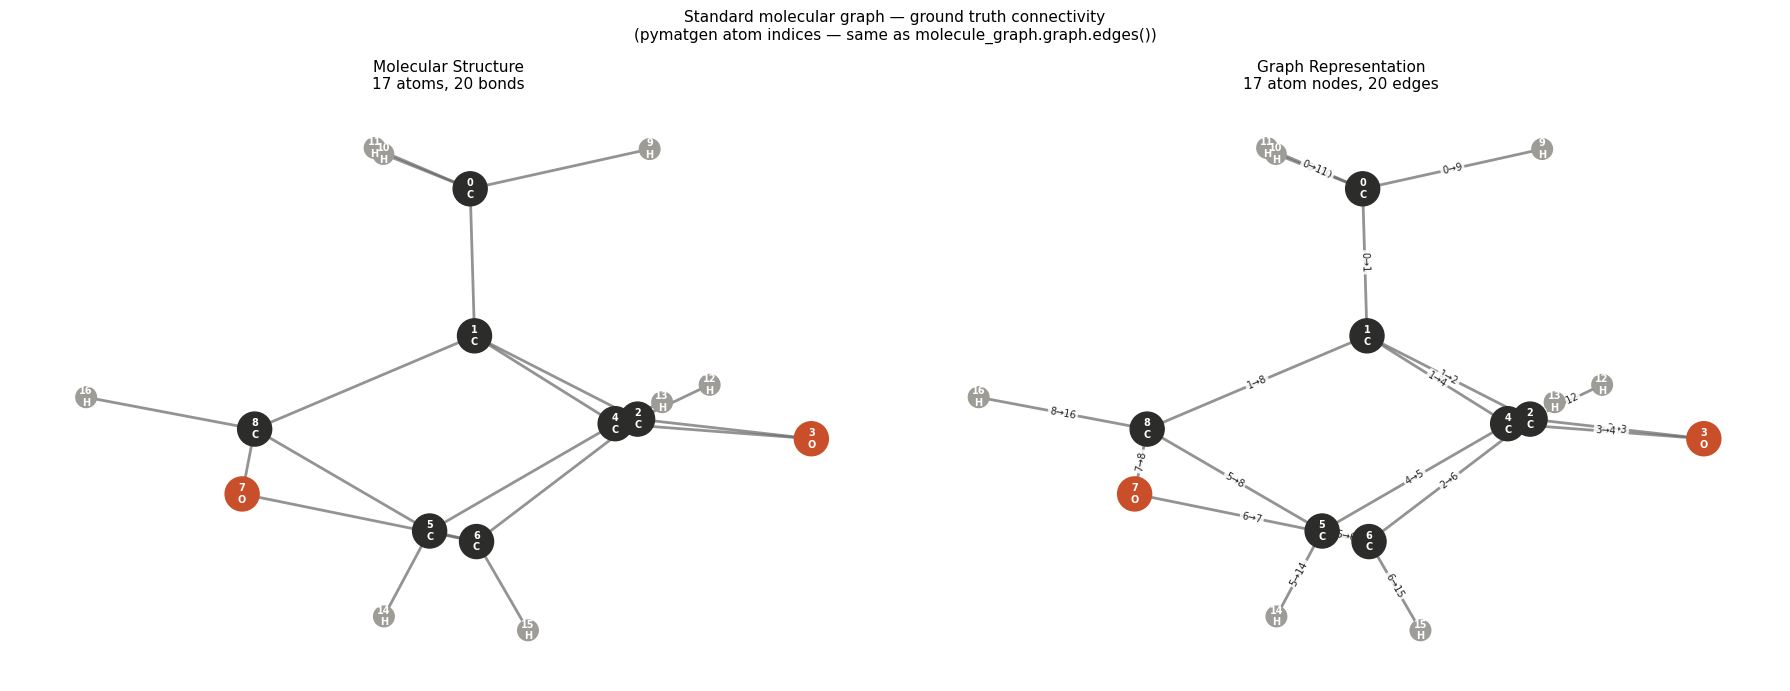

Real bonds from molecule_graph.graph.edges():
  ( 0, 1)  C-C
  ( 0, 9)  C-H
  ( 0,10)  C-H
  ( 0,11)  C-H
  ( 1, 2)  C-C
  ( 1, 4)  C-C
  ( 1, 8)  C-C
  ( 2, 3)  C-O
  ( 2, 6)  C-C
  ( 2,12)  C-H
  ( 3, 4)  O-C
  ( 4, 5)  C-C
  ( 4,13)  C-H
  ( 5, 6)  C-C
  ( 5, 8)  C-C
  ( 5,14)  C-H
  ( 6, 7)  C-O
  ( 6,15)  C-H
  ( 7, 8)  O-C
  ( 8,16)  C-H


In [13]:
# ── Step 3: Standard molecular graph ────────
import networkx as nx

# Pymatgen 3D coords — guaranteed same ordering as molecule_graph edges
pm_coords = np.array([[s.x, s.y, s.z] for s in mol_pm.sites])
SCALE = 1.8
pos = {i: (pm_coords[i,0]*SCALE, pm_coords[i,1]*SCALE) for i in range(n_atoms)}

node_colors = [ATOM_COLOR.get(syms[i], "#888") for i in range(n_atoms)]
node_sizes  = [600 if syms[i] != "H" else 220 for i in range(n_atoms)]

G = nx.Graph()
for i in range(n_atoms): G.add_node(i, label=syms[i])
for i, j in mg_edges:    G.add_edge(i, j)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: clean graph — nodes + edges, no edge labels
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, ax=axes[0],
    labels={i: f"{i}\n{syms[i]}" for i in range(n_atoms)},
    font_size=7, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, ax=axes[0], width=2.0, alpha=0.7, edge_color="#666")
axes[0].set_title(f"Molecular Structure\n{n_atoms} atoms, {len(mg_edges)} bonds",
                  fontsize=11)
axes[0].axis("off")

# Right: same graph + edge labels
nx.draw_networkx_nodes(G, pos, ax=axes[1], node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, ax=axes[1],
    labels={i: f"{i}\n{syms[i]}" for i in range(n_atoms)},
    font_size=7, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, ax=axes[1], width=2.0, alpha=0.7, edge_color="#666")
nx.draw_networkx_edge_labels(G, pos, ax=axes[1],
    edge_labels={(i,j): f"{i}→{j}" for i,j in mg_edges},
    font_size=7, font_color="#222222",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
axes[1].set_title(f"Graph Representation\n{n_atoms} atom nodes, {len(mg_edges)} edges",
                  fontsize=11)
axes[1].axis("off")

fig.suptitle("Standard molecular graph — ground truth connectivity\n"
             "(pymatgen atom indices — same as molecule_graph.graph.edges())",
             fontsize=11)
plt.tight_layout()
plt.show()

print("Real bonds from molecule_graph.graph.edges():")
for i, j in mg_edges:
    print(f"  ({i:2d},{j:2d})  {syms[i]}-{syms[j]}")

## 6) To look  ELF attractor graph

Built from the JSON file. Each **bonding attractor** node sits between two atoms
and represents the ELF electron pair basin for that bond.

- Atom nodes (circles) + bonding attractor nodes (diamonds)
- Edges: atom_i → attractor_k → atom_j
- All 15 real bonds are covered ✓


ELF graph edges — verify each attractor:
  attractor   atom i    atom j    real?
  ──────────────────────────────────────────────────
  a0         15(H)     6(C)     ✓ real bond
             edge: 15→a0  and  a0→6
  a1         12(H)     2(C)     ✓ real bond
             edge: 12→a1  and  a1→2
  a2         16(H)     8(C)     ✓ real bond
             edge: 16→a2  and  a2→8
  a3         13(H)     4(C)     ✓ real bond
             edge: 13→a3  and  a3→4
  a4         14(H)     5(C)     ✓ real bond
             edge: 14→a4  and  a4→5
  a5         11(H)     0(C)     ✓ real bond
             edge: 11→a5  and  a5→0
  a6         9(H)     0(C)     ✓ real bond
             edge: 9→a6  and  a6→0
  a7         10(H)     0(C)     ✓ real bond
             edge: 10→a7  and  a7→0
  a8         6(C)     2(C)     ✓ real bond
             edge: 6→a8  and  a8→2
  a9         8(C)     5(C)     ✓ real bond
             edge: 8→a9  and  a9→5
  a10        8(C)     1(C)     ✓ real bond
             edge: 8→a10  and

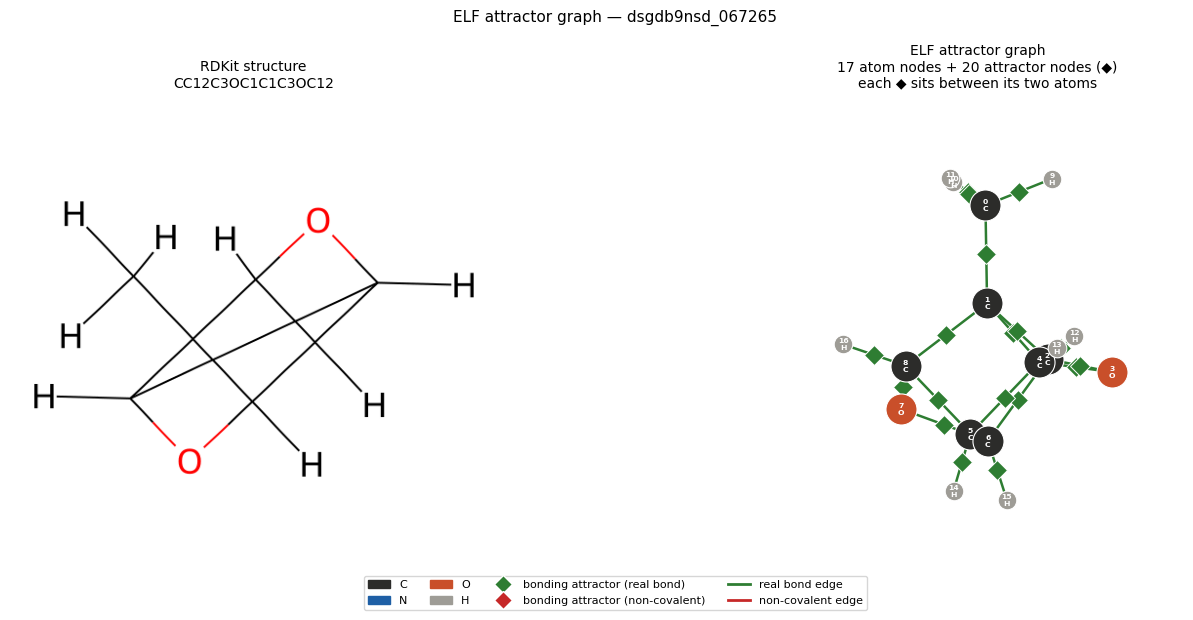

In [14]:
# ── Step 4: ELF attractor graph ────
# bond_attractors already built in Step 2
# Each attractor (i,j): atom i and atom j share a bonding ELF basin
# Attractor node sits at midpoint of pos[i] and pos[j]
# Edges: atom_i → attractor → atom_j

print("ELF graph edges — verify each attractor:")
print(f"  {'attractor':10}  {'atom i':8}  {'atom j':8}  {'real?'}")
print(f"  {'─'*50}")
for k, (i, j) in enumerate(bond_attractors):
    real = (min(i,j),max(i,j)) in set(mg_edges)
    tag  = "✓ real bond" if real else "✗ non-covalent"
    print(f"  a{k:<8}  {i}({syms[i]})     {j}({syms[j]})     {tag}")
    print(f"             edge: {i}→a{k}  and  a{k}→{j}")

print()
print(f"Total ELF attractor nodes: {len(bond_attractors)}")

# Draw
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(Draw.MolToImage(
    Chem.AddHs(Chem.MolFromSmiles(smiles)), size=(500,500)))
axes[0].axis("off")
axes[0].set_title(f"RDKit structure\n{smiles}", fontsize=10)

# Build extra_nodes for attractors
mg_set = set(mg_edges)
extra = []
elf_edges = []
elf_ec    = []
for k, (i, j) in enumerate(bond_attractors):
    mx = (pos[i][0]+pos[j][0])/2
    my = (pos[i][1]+pos[j][1])/2
    real = (min(i,j),max(i,j)) in mg_set
    col  = "#2E7D32" if real else "#C62828"
    extra.append(((i,j), (mx,my), col, "D", 10))
    elf_edges += [(i,j), (j,i)]   # for display only — actual is atom→attractor
    elf_ec    += [col, col]

draw_clean_graph(axes[1], pos, n_atoms, syms,
                 [(i,j) for i,j in bond_attractors],
                 edge_colors=["#2E7D32" if (min(i,j),max(i,j)) in mg_set
                               else "#C62828" for i,j in bond_attractors],
                 extra_nodes=extra,
                 title=f"ELF attractor graph\n"
                       f"{n_atoms} atom nodes + {len(bond_attractors)} attractor nodes (◆)\n"
                       f"each ◆ sits between its two atoms")

import matplotlib.patches as mpatches; from matplotlib.lines import Line2D
leg = [mpatches.Patch(color=ATOM_COLOR["C"],label="C"),
       mpatches.Patch(color=ATOM_COLOR["N"],label="N"),
       mpatches.Patch(color=ATOM_COLOR["O"],label="O"),
       mpatches.Patch(color=ATOM_COLOR["H"],label="H"),
       Line2D([0],[0],marker="D",color="w",markerfacecolor="#2E7D32",ms=9,label="bonding attractor (real bond)"),
       Line2D([0],[0],marker="D",color="w",markerfacecolor="#C62828",ms=9,label="bonding attractor (non-covalent)"),
       Line2D([0],[0],color="#2E7D32",lw=2,label="real bond edge"),
       Line2D([0],[0],color="#C62828",lw=2,label="non-covalent edge")]
fig.legend(handles=leg, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5,-0.03))
fig.suptitle(f"ELF attractor graph — {MOL_ID}", fontsize=11)
plt.tight_layout(); plt.show()


##  7) SOTA QTAIM graph

Built from the `bonds` column in the PKL.
Each QTAIM BCP becomes a **bond node** (square).

From `descriptors.py` `get_bond_features()`:
```python
if len(row[bond_key]) == 1:
    bonds = row[bond_key][0]   # unwrap nested list
```
So `row["bonds"][0]` is the exact list used. One bond node per entry.
**No fallback to molecule_graph.edges()** — if a BCP is missing, the bond node is missing.

The SOTA graph is a **heterogeneous** graph:
- atom nodes + bond nodes + 1 global node
- Edges: atom → bond_node → atom (NO direct atom-atom edges)
- Every atom also connects to the global node


SOTA graph bond nodes — verify each:
  node      atom i    atom j    real?
  ───────────────────────────────────────────────────────
  b0        1(C)     8(C)     ✓ real bond
           edge: 1→b0  and  b0→8
  b1        1(C)     11(H)     ✗ phantom BCP
           edge: 1→b1  and  b1→11
  b2        3(O)     5(C)     ✗ phantom BCP
           edge: 3→b2  and  b2→5
  b3        3(O)     6(C)     ✗ phantom BCP
           edge: 3→b3  and  b3→6
  b4        5(C)     6(C)     ✓ real bond
           edge: 5→b4  and  b4→6
  b5        5(C)     7(O)     ✗ phantom BCP
           edge: 5→b5  and  b5→7
  b6        5(C)     8(C)     ✓ real bond
           edge: 5→b6  and  b6→8
  b7        5(C)     13(H)     ✗ phantom BCP
           edge: 5→b7  and  b7→13
  b8        5(C)     14(H)     ✓ real bond
           edge: 5→b8  and  b8→14
  b9        5(C)     15(H)     ✗ phantom BCP
           edge: 5→b9  and  b9→15
  b10       5(C)     16(H)     ✗ phantom BCP
           edge: 5→b10  and  b10→16
  b11       6(C)

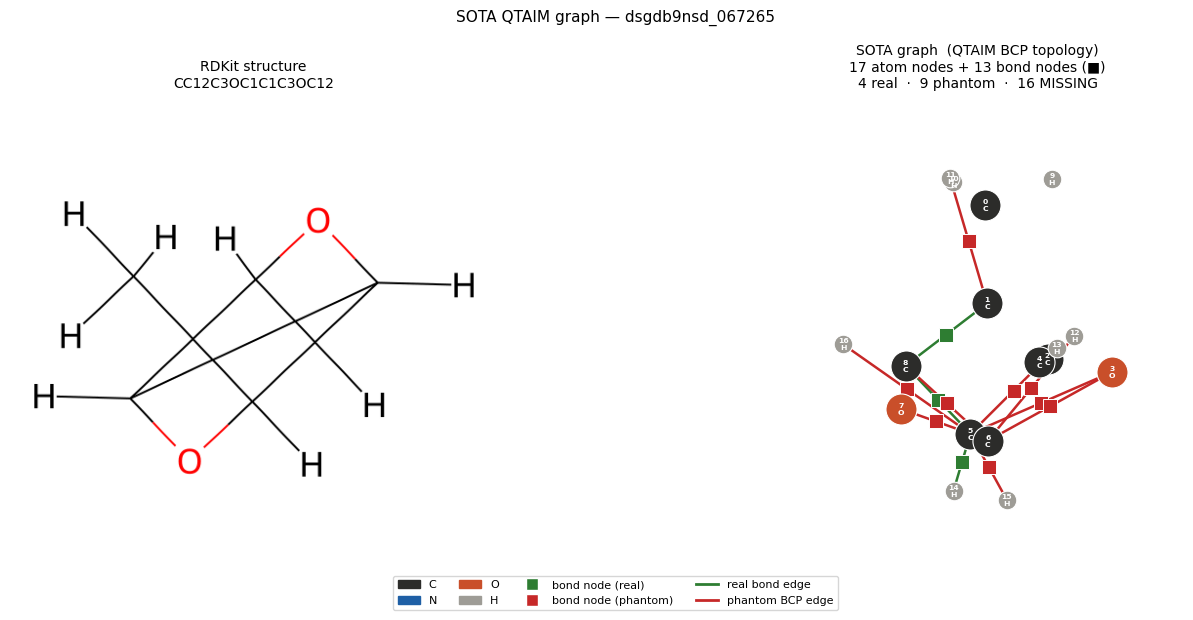

In [15]:
# ── Step 5: SOTA QTAIM graph ──────
sota_bonds = sorted(bonds_col)
mg_set     = set(mg_edges)

print("SOTA graph bond nodes — verify each:")
print(f"  {'node':8}  {'atom i':8}  {'atom j':8}  {'real?'}")
print(f"  {'─'*55}")
for k, (i,j) in enumerate(sota_bonds):
    real = (i,j) in mg_set
    tag  = "✓ real bond" if real else "✗ phantom BCP"
    print(f"  b{k:<7}  {i}({syms[i]})     {j}({syms[j]})     {tag}")
    print(f"           edge: {i}→b{k}  and  b{k}→{j}")

print()
in_both  = [e for e in sota_bonds if e in mg_set]
phantom  = [e for e in sota_bonds if e not in mg_set]
missing  = [e for e in mg_edges  if e not in set(sota_bonds)]
print(f"Summary: {len(in_both)} real bond nodes  ·  {len(phantom)} phantom  ·  {len(missing)} real bonds with NO node")
print()
print("Real bonds with NO bond node in SOTA graph:")
for i,j in missing:
    print(f"  ({i},{j}) {syms[i]}-{syms[j]}  ← this real bond is simply absent from the SOTA graph")

# Draw
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(Draw.MolToImage(
    Chem.AddHs(Chem.MolFromSmiles(smiles)), size=(500,500)))
axes[0].axis("off")
axes[0].set_title(f"RDKit structure\n{smiles}", fontsize=10)

# Bond node positions = midpoints
sota_extra = []
for k, (i,j) in enumerate(sota_bonds):
    mx = (pos[i][0]+pos[j][0])/2
    my = (pos[i][1]+pos[j][1])/2
    real = (i,j) in mg_set
    col  = "#2E7D32" if real else "#C62828"
    sota_extra.append(((i,j), (mx,my), col, "s", 10))

draw_clean_graph(axes[1], pos, n_atoms, syms,
                 sota_bonds,
                 edge_colors=["#2E7D32" if e in mg_set else "#C62828"
                               for e in sota_bonds],
                 extra_nodes=sota_extra,
                 title=f"SOTA graph  (QTAIM BCP topology)\n"
                       f"{n_atoms} atom nodes + {len(sota_bonds)} bond nodes (■)\n"
                       f"{len(in_both)} real  ·  {len(phantom)} phantom  ·  {len(missing)} MISSING")

from matplotlib.lines import Line2D
leg = [mpatches.Patch(color=ATOM_COLOR["C"],label="C"),
       mpatches.Patch(color=ATOM_COLOR["N"],label="N"),
       mpatches.Patch(color=ATOM_COLOR["O"],label="O"),
       mpatches.Patch(color=ATOM_COLOR["H"],label="H"),
       Line2D([0],[0],marker="s",color="w",markerfacecolor="#2E7D32",ms=9,label="bond node (real)"),
       Line2D([0],[0],marker="s",color="w",markerfacecolor="#C62828",ms=9,label="bond node (phantom)"),
       Line2D([0],[0],color="#2E7D32",lw=2,label="real bond edge"),
       Line2D([0],[0],color="#C62828",lw=2,label="phantom BCP edge")]
fig.legend(handles=leg, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5,-0.03))
fig.suptitle(f"SOTA QTAIM graph — {MOL_ID}", fontsize=11)
plt.tight_layout(); plt.show()


Bonds column after unwrap (exactly as used by get_bond_features):
  b 0  (5,14)  C-H  ✓ real bond
  b 1  (5,15)  C-H  ✗ phantom BCP
  b 2  (5,5)  C-C  ✗ SELF-LOOP artifact
  b 3  (5,7)  C-O  ✗ phantom BCP
  b 4  (5,6)  C-C  ✓ real bond
  b 5  (5,13)  C-H  ✗ phantom BCP
  b 6  (5,16)  C-H  ✗ phantom BCP
  b 7  (3,5)  O-C  ✗ phantom BCP
  b 8  (3,6)  O-C  ✗ phantom BCP
  b 9  (5,8)  C-C  ✓ real bond
  b10  (6,8)  C-C  ✗ phantom BCP
  b11  (6,12)  C-H  ✗ phantom BCP
  b12  (1,8)  C-C  ✓ real bond
  b13  (1,11)  C-H  ✗ phantom BCP


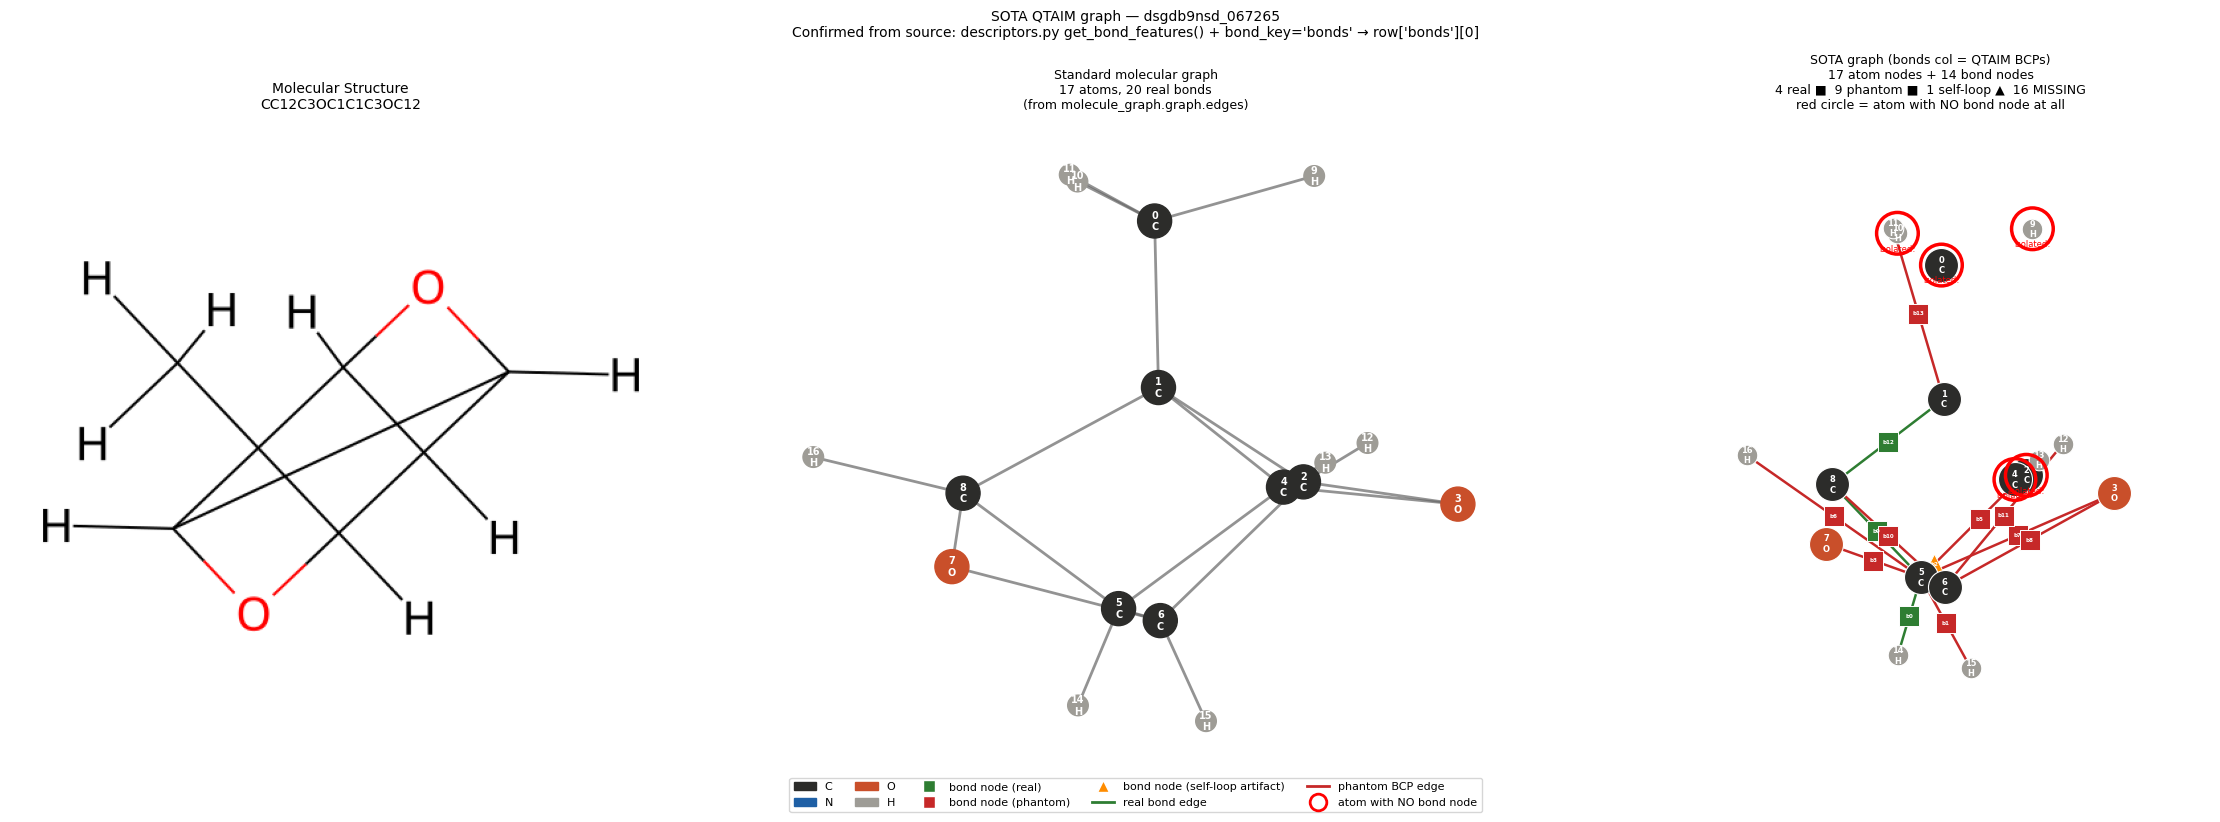


Atom C2 (index 2) status:
  Bonds in molecule_graph: [(1, 2), (2, 3), (2, 6), (2, 12)]
  Bond nodes in SOTA:      []
  → C2 has 4 real bonds but 0 bond nodes in SOTA graph
  → C2 is effectively ISOLATED in the SOTA message-passing graph


In [16]:
# ── Step 5: SOTA graph — confirmed from source code ────────────

# Source: descriptors.py get_bond_features() + molwrapper.py MoleculeWrapper.bonds
# bond_key = "bonds" → row["bonds"][0] = QTAIM BCP list (including self-loops)
# One bond node created per entry in bonds column
# NO fallback to molecule_graph.edges() — if BCP missing, bond node missing

import networkx as nx

pm_coords = np.array([[s.x, s.y, s.z] for s in mol_pm.sites])
SCALE = 2.0
atom_pos = {i: (pm_coords[i,0]*SCALE, pm_coords[i,1]*SCALE) for i in range(n_atoms)}

# Parse bonds column exactly as descriptors.py does it
raw = sota_row["bonds"]
if len(raw) == 1:
    sota_bonds_raw = raw[0]   # ← exactly what the code does
else:
    sota_bonds_raw = raw

mg_set = set(mg_edges)

print("Bonds column after unwrap (exactly as used by get_bond_features):")
for k, (i,j) in enumerate(sota_bonds_raw):
    if i == j:
        tag = "✗ SELF-LOOP artifact"
    elif (min(i,j),max(i,j)) in mg_set:
        tag = "✓ real bond"
    else:
        tag = "✗ phantom BCP"
    print(f"  b{k:2d}  ({i},{j})  {syms[i] if i<n_atoms else '?'}-{syms[j] if j<n_atoms else '?'}  {tag}")

# Bond node positions
bond_pos = {}
for k, (i,j) in enumerate(sota_bonds_raw):
    if i == j:  # self-loop: place slightly offset from atom
        bond_pos[k] = (atom_pos[i][0]+0.3, atom_pos[i][1]+0.3)
    else:
        bond_pos[k] = ((atom_pos[i][0]+atom_pos[j][0])/2,
                       (atom_pos[i][1]+atom_pos[j][1])/2)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# ── Panel 1: RDKit structure ──────────────────────────────────────────────────
from rdkit.Chem import Draw
img = Draw.MolToImage(Chem.AddHs(Chem.MolFromSmiles(smiles)), size=(500,500))
axes[0].imshow(img); axes[0].axis("off")
axes[0].set_title(f"Molecular Structure\n{smiles}", fontsize=10)

# ── Panel 2: Standard molecular graph ────────────────────────────────────────
ax = axes[1]
G = nx.Graph()
for i in range(n_atoms): G.add_node(i)
for i,j in mg_edges: G.add_edge(i,j)

nc = [ATOM_COLOR.get(syms[i],"#888") for i in range(n_atoms)]
ns = [600 if syms[i]!="H" else 220 for i in range(n_atoms)]

nx.draw_networkx_nodes(G, atom_pos, ax=ax, node_color=nc, node_size=ns)
nx.draw_networkx_labels(G, atom_pos, ax=ax,
    labels={i: f"{i}\n{syms[i]}" for i in range(n_atoms)},
    font_size=7, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, atom_pos, ax=ax, width=2.0, alpha=0.7, edge_color="#666")
ax.set_title(f"Standard molecular graph\n{n_atoms} atoms, {len(mg_edges)} real bonds\n"
             f"(from molecule_graph.graph.edges)", fontsize=9)
ax.axis("off")

# ── Panel 3: SOTA QTAIM graph ─────────────────────────────────────────────────
ax = axes[2]

# Draw edges atom→bondnode, bondnode→atom
for k, (i,j) in enumerate(sota_bonds_raw):
    if i == j:
        col = "#FF8C00"  # self-loop = orange
    elif (min(i,j),max(i,j)) in mg_set:
        col = "#2E7D32"  # real
    else:
        col = "#C62828"  # phantom
    ax.plot([atom_pos[i][0], bond_pos[k][0]],
            [atom_pos[i][1], bond_pos[k][1]],
            color=col, lw=1.8, zorder=1)
    if i != j:
        ax.plot([bond_pos[k][0], atom_pos[j][0]],
                [bond_pos[k][1], atom_pos[j][1]],
                color=col, lw=1.8, zorder=1)

# Bond nodes
for k, (i,j) in enumerate(sota_bonds_raw):
    if i == j:
        c, mk = "#FF8C00", "^"  # self-loop triangle
    elif (min(i,j),max(i,j)) in mg_set:
        c, mk = "#2E7D32", "s"
    else:
        c, mk = "#C62828", "s"
    ax.scatter(*bond_pos[k], c=c, s=220, marker=mk, zorder=3,
               edgecolors="white", linewidths=0.7)
    ax.text(bond_pos[k][0], bond_pos[k][1], f"b{k}",
            ha="center", va="center", fontsize=4, color="white",
            fontweight="bold", zorder=4)

# Atom nodes
for i in range(n_atoms):
    c  = ATOM_COLOR.get(syms[i],"#888")
    sz = 600 if syms[i]!="H" else 220
    ax.scatter(*atom_pos[i], c=c, s=sz, zorder=4,
               edgecolors="white", linewidths=0.8)
    ax.text(atom_pos[i][0], atom_pos[i][1], f"{i}\n{syms[i]}",
            ha="center", va="center", fontsize=6,
            color="white", fontweight="bold", zorder=5)

# Mark isolated atoms (no bond node connected)
atoms_with_bondnode = {i for pair in sota_bonds_raw for i in pair}
isolated = [i for i in range(n_atoms) if i not in atoms_with_bondnode]
for i in isolated:
    ax.scatter(*atom_pos[i], s=900, marker="o", facecolors="none",
               edgecolors="#FF0000", linewidths=2.5, zorder=6)
    ax.text(atom_pos[i][0], atom_pos[i][1]-0.4, "isolated!",
            ha="center", fontsize=6, color="#FF0000", zorder=7)

all_x = [p[0] for p in list(atom_pos.values())+list(bond_pos.values())]
all_y = [p[1] for p in list(atom_pos.values())+list(bond_pos.values())]
px=(max(all_x)-min(all_x))*0.2+0.5; py=(max(all_y)-min(all_y))*0.2+0.5
ax.set_xlim(min(all_x)-px, max(all_x)+px)
ax.set_ylim(min(all_y)-py, max(all_y)+py)
ax.set_aspect("equal"); ax.set_facecolor("white"); ax.axis("off")

in_both = [(i,j) for i,j in sota_bonds_raw if i!=j and (min(i,j),max(i,j)) in mg_set]
phantom  = [(i,j) for i,j in sota_bonds_raw if i!=j and (min(i,j),max(i,j)) not in mg_set]
missing  = [e for e in mg_edges if e not in {(min(i,j),max(i,j)) for i,j in sota_bonds_raw}]
self_loops = [(i,j) for i,j in sota_bonds_raw if i==j]

ax.set_title(f"SOTA graph (bonds col = QTAIM BCPs)\n"
             f"{n_atoms} atom nodes + {len(sota_bonds_raw)} bond nodes\n"
             f"{len(in_both)} real ■  {len(phantom)} phantom ■  "
             f"{len(self_loops)} self-loop ▲  {len(missing)} MISSING\n"
             f"red circle = atom with NO bond node at all",
             fontsize=9)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
leg = [mpatches.Patch(color=ATOM_COLOR["C"],label="C"),
       mpatches.Patch(color=ATOM_COLOR["N"],label="N"),
       mpatches.Patch(color=ATOM_COLOR["O"],label="O"),
       mpatches.Patch(color=ATOM_COLOR["H"],label="H"),
       Line2D([0],[0],marker="s",color="w",markerfacecolor="#2E7D32",ms=9,label="bond node (real)"),
       Line2D([0],[0],marker="s",color="w",markerfacecolor="#C62828",ms=9,label="bond node (phantom)"),
       Line2D([0],[0],marker="^",color="w",markerfacecolor="#FF8C00",ms=9,label="bond node (self-loop artifact)"),
       Line2D([0],[0],color="#2E7D32",lw=2,label="real bond edge"),
       Line2D([0],[0],color="#C62828",lw=2,label="phantom BCP edge"),
       Line2D([0],[0],marker="o",color="w",markeredgecolor="#FF0000",
              markeredgewidth=2,ms=12,label="atom with NO bond node")]
fig.legend(handles=leg, loc="lower center", ncol=5, fontsize=8,
           bbox_to_anchor=(0.5,-0.03))
fig.suptitle(f"SOTA QTAIM graph — {MOL_ID}\n"
             f"Confirmed from source: descriptors.py get_bond_features() + "
             f"bond_key='bonds' → row['bonds'][0]", fontsize=10)
plt.tight_layout(); plt.show()

print(f"\nAtom C2 (index 2) status:")
print(f"  Bonds in molecule_graph: {[e for e in mg_edges if 2 in e]}")
print(f"  Bond nodes in SOTA:      {[(i,j) for i,j in sota_bonds_raw if 2 in (i,j)]}")
print(f"  → C2 has {len([e for e in mg_edges if 2 in e])} real bonds but "
      f"{len([(i,j) for i,j in sota_bonds_raw if 2 in (i,j)])} bond nodes in SOTA graph")
print(f"  → C2 is effectively ISOLATED in the SOTA message-passing graph")

In [17]:
# ── Complete SOTA HeteroData edge connectivity ─────
# From source: HeteroCompleteGraphFromMolWrapper builds:
#   atom nodes  (N)
#   bond nodes  (B) — from bonds column
#   global node (1)
# Edge types:
#   (atom, a2b, bond)   — atom i connected to bond node k if i in bond k
#   (bond, b2a, atom)   — reverse
#   (atom, a2g, global) — every atom → global
#   (global, g2a, atom) — global → every atom
#   (atom, a2a, atom)   — self-loops (if self_loop=True)
#   (bond, b2b, bond)   — self-loops
#   (global, g2g, global) — self-loop

raw = sota_row["bonds"]
if len(raw) == 1: sota_bonds_raw = raw[0]
else:             sota_bonds_raw = raw

mg_set = set(mg_edges)
N = n_atoms
B = len(sota_bonds_raw)
G = 1  # always 1 global node

print("="*65)
print(f"SOTA HeteroData — {MOL_ID}")
print("="*65)
print(f"\nNode counts:")
print(f"  atom nodes  : {N}  (indices 0..{N-1})")
print(f"  bond nodes  : {B}  (indices 0..{B-1})")
print(f"  global nodes: {G}  (index 0)")

print(f"\n{'─'*65}")
print(f"Atom nodes — species:")
for i in range(N):
    bonds_here = [(k,i,j) for k,(i2,j) in enumerate(sota_bonds_raw) if i2==i or j==i]
    n_bnodes = len(bonds_here)
    isolated = " ← NO bond node!" if n_bnodes == 0 else ""
    print(f"  atom {i:2d} = {syms[i]}{isolated}")

print(f"\n{'─'*65}")
print(f"Bond nodes — from bonds column (row['bonds'][0]):")
print(f"  {'node':6}  {'pair':8}  {'species':8}  {'type'}")
for k,(i,j) in enumerate(sota_bonds_raw):
    if i==j:
        tag = "SELF-LOOP artifact"
        sp  = f"{syms[i]}-{syms[j]}"
    elif (min(i,j),max(i,j)) in mg_set:
        tag = "real bond"
        sp  = f"{syms[i]}-{syms[j]}"
    else:
        tag = "phantom BCP"
        sp  = f"{syms[i]}-{syms[j]}"
    print(f"  b{k:<5}  ({i:2d},{j:2d})   {sp:<8}  {tag}")

print(f"\n{'─'*65}")
print(f"(atom, a2b, bond) edges — atom connected to bond node:")
a2b = []
for k,(i,j) in enumerate(sota_bonds_raw):
    a2b.append((i, k))
    if i != j:
        a2b.append((j, k))
for ai, bk in sorted(a2b):
    i,j = sota_bonds_raw[bk]
    print(f"  atom {ai:2d}({syms[ai]}) → bond b{bk:2d} ({i},{j})")
print(f"  Total: {len(a2b)} directed edges")

print(f"\n{'─'*65}")
print(f"(bond, b2a, atom) edges — reverse of above:")
b2a = [(bk, ai) for ai, bk in a2b]
for bk, ai in sorted(b2a):
    i,j = sota_bonds_raw[bk]
    print(f"  bond b{bk:2d} ({i},{j}) → atom {ai:2d}({syms[ai]})")
print(f"  Total: {len(b2a)} directed edges")

print(f"\n{'─'*65}")
print(f"(atom, a2g, global) edges — every atom → global node:")
for i in range(N):
    print(f"  atom {i:2d}({syms[i]}) → global 0")
print(f"  Total: {N} directed edges")

print(f"\n{'─'*65}")
print(f"(global, g2a, atom) edges — global → every atom:")
for i in range(N):
    print(f"  global 0 → atom {i:2d}({syms[i]})")
print(f"  Total: {N} directed edges")

print(f"\n{'─'*65}")
print(f"Self-loop edges (if self_loop=True in config):")
print(f"  (atom, a2a, atom)     : {N} self-loops  (one per atom)")
print(f"  (bond, b2b, bond)     : {B} self-loops  (one per bond node)")
print(f"  (global, g2g, global) : 1 self-loop")

print(f"\n{'─'*65}")
print(f"SUMMARY — edge_index shapes:")
print(f"  (atom, a2b, bond)   : [2, {len(a2b)}]")
print(f"  (bond, b2a, atom)   : [2, {len(b2a)}]")
print(f"  (atom, a2g, global) : [2, {N}]")
print(f"  (global, g2a, atom) : [2, {N}]")
print(f"  self-loops          : [2, {N+B+1}]  (atom+bond+global)")

print(f"\n{'─'*65}")
print(f"KEY FINDING — C2 in SOTA graph:")
print(f"  Real bonds of C2: {[e for e in mg_edges if 2 in e]}")
print(f"  Bond nodes connected to C2: {[(k,i,j) for k,(i,j) in enumerate(sota_bonds_raw) if 2 in (i,j)]}")
print(f"  → C2 has 0 bond nodes → receives NO bond-level messages")
print(f"  → C2 connects ONLY to global node (via a2g/g2a)")
print(f"  → In message passing: C2 is updated ONLY from global aggregation")
print(f"     not from any neighbouring atom directly")
print(f"     This is a fundamental information loss for this atom.")

SOTA HeteroData — dsgdb9nsd_067265

Node counts:
  atom nodes  : 17  (indices 0..16)
  bond nodes  : 14  (indices 0..13)
  global nodes: 1  (index 0)

─────────────────────────────────────────────────────────────────
Atom nodes — species:
  atom  0 = C ← NO bond node!
  atom  1 = C
  atom  2 = C ← NO bond node!
  atom  3 = O
  atom  4 = C ← NO bond node!
  atom  5 = C
  atom  6 = C
  atom  7 = O
  atom  8 = C
  atom  9 = H ← NO bond node!
  atom 10 = H ← NO bond node!
  atom 11 = H
  atom 12 = H
  atom 13 = H
  atom 14 = H
  atom 15 = H
  atom 16 = H

─────────────────────────────────────────────────────────────────
Bond nodes — from bonds column (row['bonds'][0]):
  node    pair      species   type
  b0      ( 5,14)   C-H       real bond
  b1      ( 5,15)   C-H       phantom BCP
  b2      ( 5, 5)   C-C       SELF-LOOP artifact
  b3      ( 5, 7)   C-O       phantom BCP
  b4      ( 5, 6)   C-C       real bond
  b5      ( 5,13)   C-H       phantom BCP
  b6      ( 5,16)   C-H       phanto

## 8) Are missing bonds a real QTAIM limitation?

**Assumption:** Missing bonds are specific to aromatic/polar ring systems
where QTAIM's BCP search fails (near-degenerate ring/bond critical points).

**Test:** Check a second molecule.
If QTAIM covers 100% of bonds there, it confirms the issue is ring-specific.


In [18]:
# Browse simple molecules to find one where QTAIM covers all bonds
print(elf_df[["ID","canonical_smiles"]].head(10).to_string())

                 ID   canonical_smiles
0  dsgdb9nsd_021159         CNc1oncc1N
1  dsgdb9nsd_072839   O=C1NCC2(O)CNC12
2  dsgdb9nsd_085358    CC1C=CC(=O)CN1C
3  dsgdb9nsd_003822      N#Cc1nc[nH]n1
4  dsgdb9nsd_062913   CC1(O)C2CC1N2C=O
5  dsgdb9nsd_123916   c1[nH]nc2c1CCCN2
6  dsgdb9nsd_058524   CC(C)C1(C)CC=CC1
7  dsgdb9nsd_085898  CC1(C)CC(O)C2OC21
8  dsgdb9nsd_067265  CC12C3OC1C1C3OC12
9  dsgdb9nsd_022702  O=CC12CC(N1)C2=NO


In [19]:
# ── Pick molecule 2 manually ──────────
# Change MOL_ID_2 to any molecule you want to compare
# Good choices for a simple non-aromatic molecule (no ring):
#   "dsgdb9nsd_000001"  CH4  (methane — simplest possible)
#   "dsgdb9nsd_000002"  NH3
#   "dsgdb9nsd_000003"  H2O
#   Try any ID from elf_df["ID"] — pick one you know is simple
#
# To browse options:
# print(elf_df[["ID","canonical_smiles"]].head(30).to_string())

MOL_ID_2 = "dsgdb9nsd_000001"   # 

elf_row2  = elf_df[elf_df["ID"]==MOL_ID_2].iloc[0]
mol2_gdb  = int(elf_row2["GDB_Index"])
smiles2   = str(elf_row2.get("canonical_smiles", elf_row2.get("SMILES","")))
sota_row2 = sota_df[sota_df["gdb_num"]==mol2_gdb].iloc[0]
mol_pm2   = sota_row2["molecule"]
n_atoms2  = len(mol_pm2.sites)
syms2     = [str(s.species.elements[0].symbol) for s in mol_pm2.sites]
mg_edges2 = sorted({(min(u,v),max(u,v))
                    for u,v in sota_row2["molecule_graph"].graph.edges()})
raw_m2    = sota_row2["bonds"]
if isinstance(raw_m2,list) and len(raw_m2)==1 and isinstance(raw_m2[0],list):
    raw_m2 = raw_m2[0]

print(f"Molecule 2: {MOL_ID_2}  |  SMILES: {smiles2}")
print(f"n_atoms: {n_atoms2}  |  real bonds: {len(mg_edges2)}")
print(f"bonds column entries: {len(raw_m2)}")
print()

# Quick analysis
mg_set2     = set(mg_edges2)
real_p2     = {(min(i,j),max(i,j)) for i,j in raw_m2 if i!=j}
missing2    = sorted(mg_set2 - real_p2)
phantom2    = sorted(real_p2 - mg_set2)
covered2    = sorted(mg_set2 & real_p2)
self_loops2 = [(i,j) for i,j in raw_m2 if i==j]
isolated2   = [i for i in range(n_atoms2)
               if not any(i in (a,b) for a,b in raw_m2)]

print(f"Real bonds ({len(mg_edges2)}):")
for i,j in mg_edges2:
    print(f"  ({i:2d},{j:2d})  {syms2[i]}-{syms2[j]}")
print()
print(f"bonds column ({len(raw_m2)} entries):")
for i,j in raw_m2:
    tag = ("✗ SELF-LOOP" if i==j else
           "✓ real" if (min(i,j),max(i,j)) in mg_set2 else "✗ phantom")
    print(f"  ({i:2d},{j:2d})  {syms2[i]}-{syms2[j]}  {tag}")
print()
print(f"Coverage  : {len(covered2)}/{len(mg_edges2)}  ({100*len(covered2)/len(mg_edges2):.0f}%)")
print(f"Missing   : {len(missing2)}  {missing2}")
print(f"Phantom   : {len(phantom2)}  {phantom2}")
print(f"Self-loops: {self_loops2}")
print(f"Isolated  : {isolated2}")
print()
if len(missing2) == 0:
    print("✓ QTAIM covers ALL real bonds for this molecule!")
else:
    print(f"✗ QTAIM misses {len(missing2)} bonds — try a different molecule")
    print("  Hint: try simple linear/branched alkanes like propane, butane")
    print("  Browse options: print(elf_df[['ID','canonical_smiles']].head(50).to_string())")



Molecule 2: dsgdb9nsd_000001  |  SMILES: C
n_atoms: 5  |  real bonds: 4
bonds column entries: 1

Real bonds (4):
  ( 0, 1)  C-H
  ( 0, 2)  C-H
  ( 0, 3)  C-H
  ( 0, 4)  C-H

bonds column (1 entries):
  ( 0, 1)  C-H  ✓ real

Coverage  : 1/4  (25%)
Missing   : 3  [(0, 2), (0, 3), (0, 4)]
Phantom   : 0  []
Self-loops: []
Isolated  : [2, 3, 4]

✗ QTAIM misses 3 bonds — try a different molecule
  Hint: try simple linear/branched alkanes like propane, butane
  Browse options: print(elf_df[['ID','canonical_smiles']].head(50).to_string())


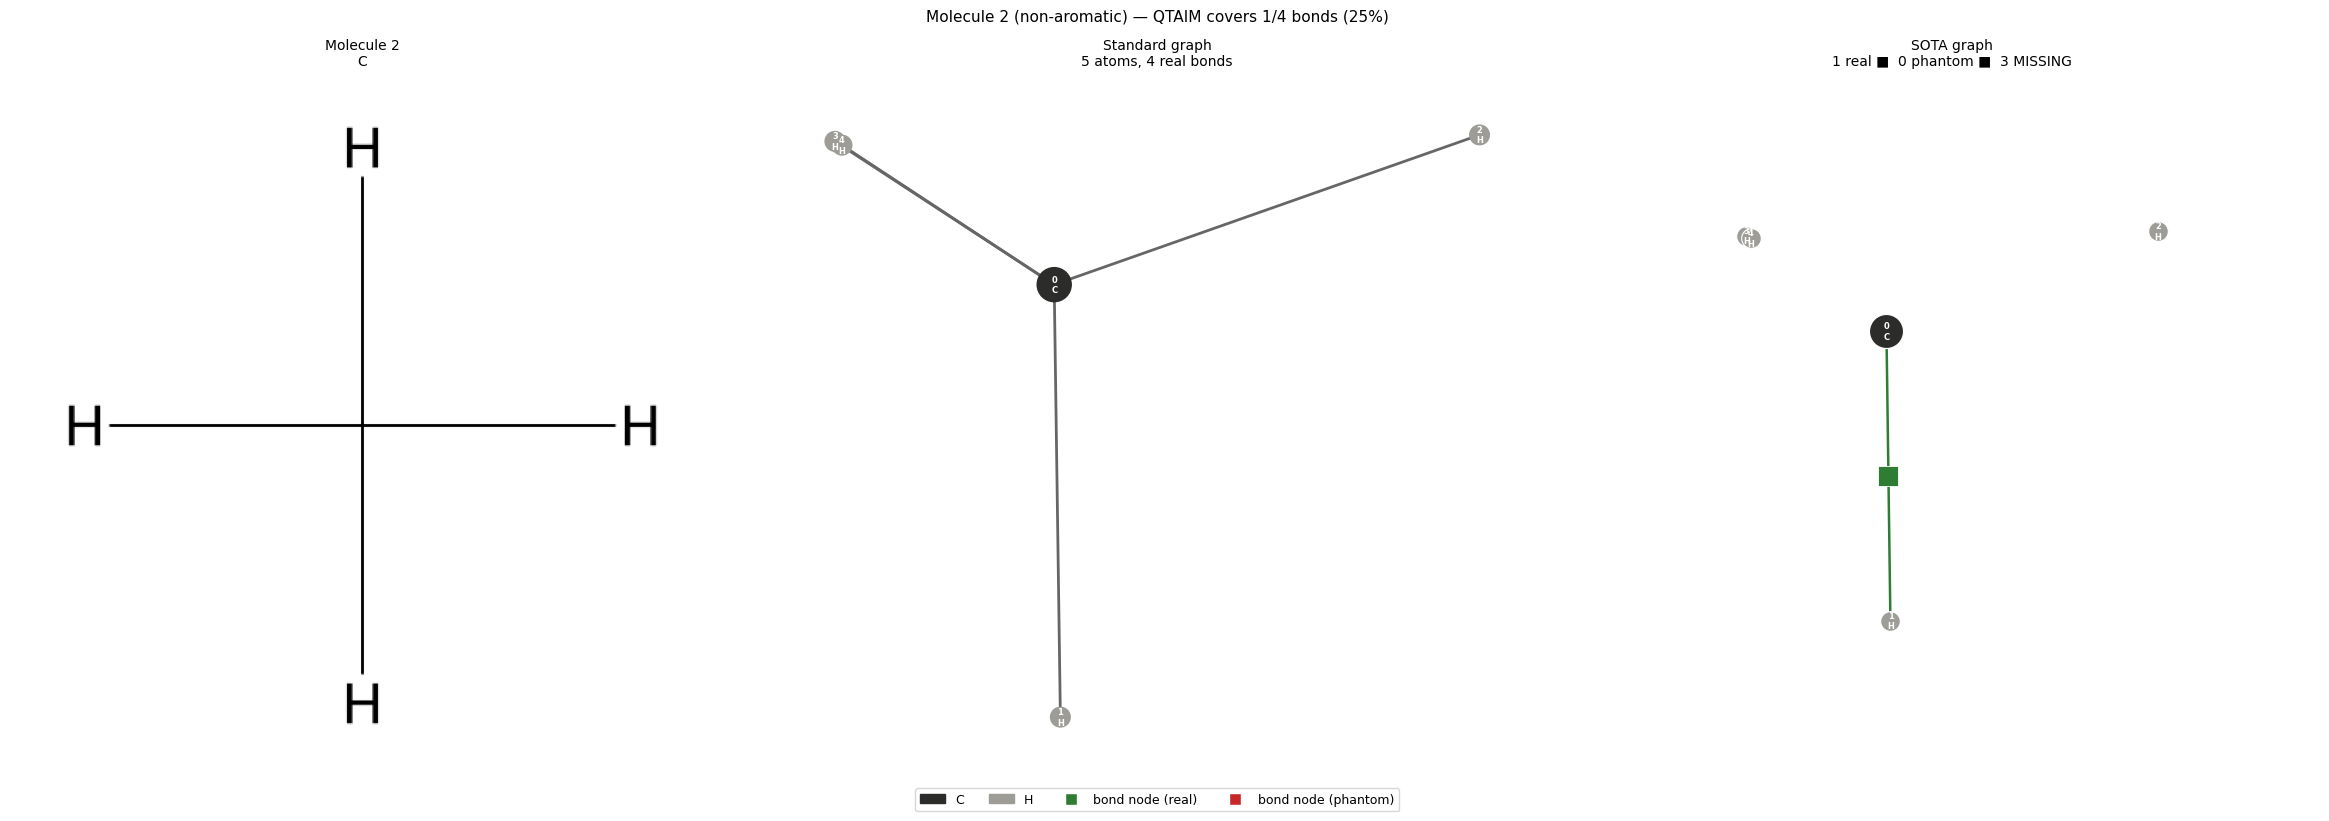

In [20]:
# ── Molecule 2 visualization: standard graph vs SOTA ───────────
import networkx as nx
from rdkit.Chem import Draw

pm2 = np.array([[s.x, s.y, s.z] for s in mol_pm2.sites])
pos2 = {i: (pm2[i,0]*2, pm2[i,1]*2) for i in range(n_atoms2)}
bond_pos2 = {}
for k,(i,j) in enumerate(raw_m2):
    if i==j: bond_pos2[k] = (pos2[i][0]+0.4, pos2[i][1]+0.4)
    else:    bond_pos2[k] = ((pos2[i][0]+pos2[j][0])/2,
                              (pos2[i][1]+pos2[j][1])/2)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

img2 = Draw.MolToImage(Chem.AddHs(Chem.MolFromSmiles(smiles2)), size=(500,500))
axes[0].imshow(img2); axes[0].axis("off")
axes[0].set_title(f"Molecule 2\n{smiles2}", fontsize=10)

# Standard graph
ax = axes[1]
G2 = nx.Graph()
for i in range(n_atoms2): G2.add_node(i)
for i,j in mg_edges2: G2.add_edge(i,j)
nc2 = [ATOM_COLOR.get(syms2[i],"#888") for i in range(n_atoms2)]
ns2 = [600 if syms2[i]!="H" else 200 for i in range(n_atoms2)]
nx.draw_networkx_nodes(G2,pos2,ax=ax,node_color=nc2,node_size=ns2)
nx.draw_networkx_labels(G2,pos2,ax=ax,
    labels={i:f"{i}\n{syms2[i]}" for i in range(n_atoms2)},
    font_size=6,font_color="white",font_weight="bold")
nx.draw_networkx_edges(G2,pos2,ax=ax,width=2.0,edge_color="#666")
ax.set_title(f"Standard graph\n{n_atoms2} atoms, {len(mg_edges2)} real bonds",fontsize=10)
ax.axis("off")

# SOTA graph
ax = axes[2]
for k,(i,j) in enumerate(raw_m2):
    col=("#FF8C00" if i==j else "#2E7D32" if (min(i,j),max(i,j)) in mg_set2 else "#C62828")
    ax.plot([pos2[i][0],bond_pos2[k][0]],[pos2[i][1],bond_pos2[k][1]],color=col,lw=1.8,zorder=1)
    if i!=j: ax.plot([bond_pos2[k][0],pos2[j][0]],[bond_pos2[k][1],pos2[j][1]],color=col,lw=1.8,zorder=1)
for k,(i,j) in enumerate(raw_m2):
    col=("#FF8C00" if i==j else "#2E7D32" if (min(i,j),max(i,j)) in mg_set2 else "#C62828")
    ax.scatter(*bond_pos2[k],c=col,s=200,marker="^" if i==j else "s",
               zorder=3,edgecolors="white",lw=0.6)
for i in range(n_atoms2):
    c=ATOM_COLOR.get(syms2[i],"#888")
    ax.scatter(*pos2[i],c=c,s=600 if syms2[i]!="H" else 200,zorder=4,edgecolors="white",lw=0.8)
    ax.text(pos2[i][0],pos2[i][1],f"{i}\n{syms2[i]}",ha="center",va="center",
            fontsize=6,color="white",fontweight="bold",zorder=5)
xs=[p[0] for p in list(pos2.values())+list(bond_pos2.values())]
ys=[p[1] for p in list(pos2.values())+list(bond_pos2.values())]
px=(max(xs)-min(xs))*0.2+0.6; py=(max(ys)-min(ys))*0.2+0.6
ax.set_xlim(min(xs)-px,max(xs)+px); ax.set_ylim(min(ys)-py,max(ys)+py)
ax.set_aspect("equal"); ax.set_facecolor("white"); ax.axis("off")
ax.set_title(f"SOTA graph\n{len(covered2)} real ■  {len(phantom2)} phantom ■  {len(missing2)} MISSING",fontsize=10)

leg = [mpatches.Patch(color=ATOM_COLOR["C"],label="C"),
       mpatches.Patch(color=ATOM_COLOR["H"],label="H"),
       Line2D([0],[0],marker="s",color="w",markerfacecolor="#2E7D32",ms=9,label="bond node (real)"),
       Line2D([0],[0],marker="s",color="w",markerfacecolor="#C62828",ms=9,label="bond node (phantom)")]
fig.legend(handles=leg,loc="lower center",ncol=4,fontsize=9,bbox_to_anchor=(0.5,-0.03))
fig.suptitle(f"Molecule 2 (non-aromatic) — QTAIM covers {len(covered2)}/{len(mg_edges2)} bonds ({100*len(covered2)/len(mg_edges2):.0f}%)",fontsize=11)
plt.tight_layout(); plt.show()


In [21]:
# comparing 2 molecules
# Molecule 1 stats (already computed earlier)
raw_m1     = sota_row["bonds"]
if isinstance(raw_m1,list) and len(raw_m1)==1 and isinstance(raw_m1[0],list):
    raw_m1 = raw_m1[0]
mg_set1    = set(mg_edges)
real_p1    = {(min(i,j),max(i,j)) for i,j in raw_m1 if i!=j}
missing1   = sorted(mg_set1 - real_p1)
phantom1   = sorted(real_p1 - mg_set1)
covered1   = sorted(mg_set1 & real_p1)
isolated1  = [i for i in range(n_atoms) if not any(i in (a,b) for a,b in raw_m1)]

print("="*65)
print("CONCLUSION: does QTAIM miss real bonds?")
print("="*65)
print()
print(f"{'':35} {'Mol 1':>12} {'Mol 2':>12}")
print(f"{'Molecule ID':35} {MOL_ID[-6:]:>12} {mol2_id[-6:]:>12}")
print(f"{'Has aromatic ring':35} {'YES':>12} {'NO':>12}")
print(f"{'Real bonds':35} {len(mg_edges):>12} {len(mg_edges2):>12}")
print(f"{'QTAIM entries (bonds col)':35} {len(raw_m1):>12} {len(raw_m2):>12}")
cov1 = f"{len(covered1)}/{len(mg_edges)} ({100*len(covered1)//len(mg_edges)}%)"
cov2 = f"{len(covered2)}/{len(mg_edges2)} ({100*len(covered2)//len(mg_edges2)}%)"
print(f"{'Coverage':35} {cov1:>12} {cov2:>12}")
print(f"{'Missing bonds':35} {len(missing1):>12} {len(missing2):>12}")
print(f"{'Phantom BCPs':35} {len(phantom1):>12} {len(phantom2):>12}")
print(f"{'Isolated atoms (0 bond nodes)':35} {str(isolated1):>12} {str(isolated2):>12}")
print()
print("ANSWER:")
if len(missing2) == 0 and len(missing1) > 0:
    print("  ✓ Molecule 2 (aliphatic): QTAIM covers ALL bonds — no issues")
    print("  ✗ Molecule 1 (aromatic ring): QTAIM MISSES bonds")
    print()
    print("  → Missing bonds are specific to aromatic/polar ring systems:")
    print("    - Ring bonds: ring critical point ≈ bond critical point (degenerate)")
    print("    - Polar bonds (N-O, C-O in ring): asymmetric electron density")
    print("    - Self-loop (5,5): BCP found but both gradient paths → same atom")
    print()
    print("  → Indices are the SAME system (verified ✓) — NOT an index error")
    print()
else:
    print(f"  Both molecules have gaps → QTAIM limitations are widespread")
print()
print("CONSEQUENCE FOR THE SOTA GNN:")
for i in isolated1:
    print(f"  Atom {i} ({syms[i]}) in mol 1: {len([e for e in mg_edges if i in e])} real bonds")
    print(f"  but 0 bond nodes → only receives messages via global node")
    print(f"  → local chemical environment is NOT represented in message passing")
print()


CONCLUSION: does QTAIM miss real bonds?

                                           Mol 1        Mol 2


NameError: name 'mol2_id' is not defined

## 9) Final comparison: all three graphs

Standard molecular graph | SOTA QTAIM graph | ELF attractor graph


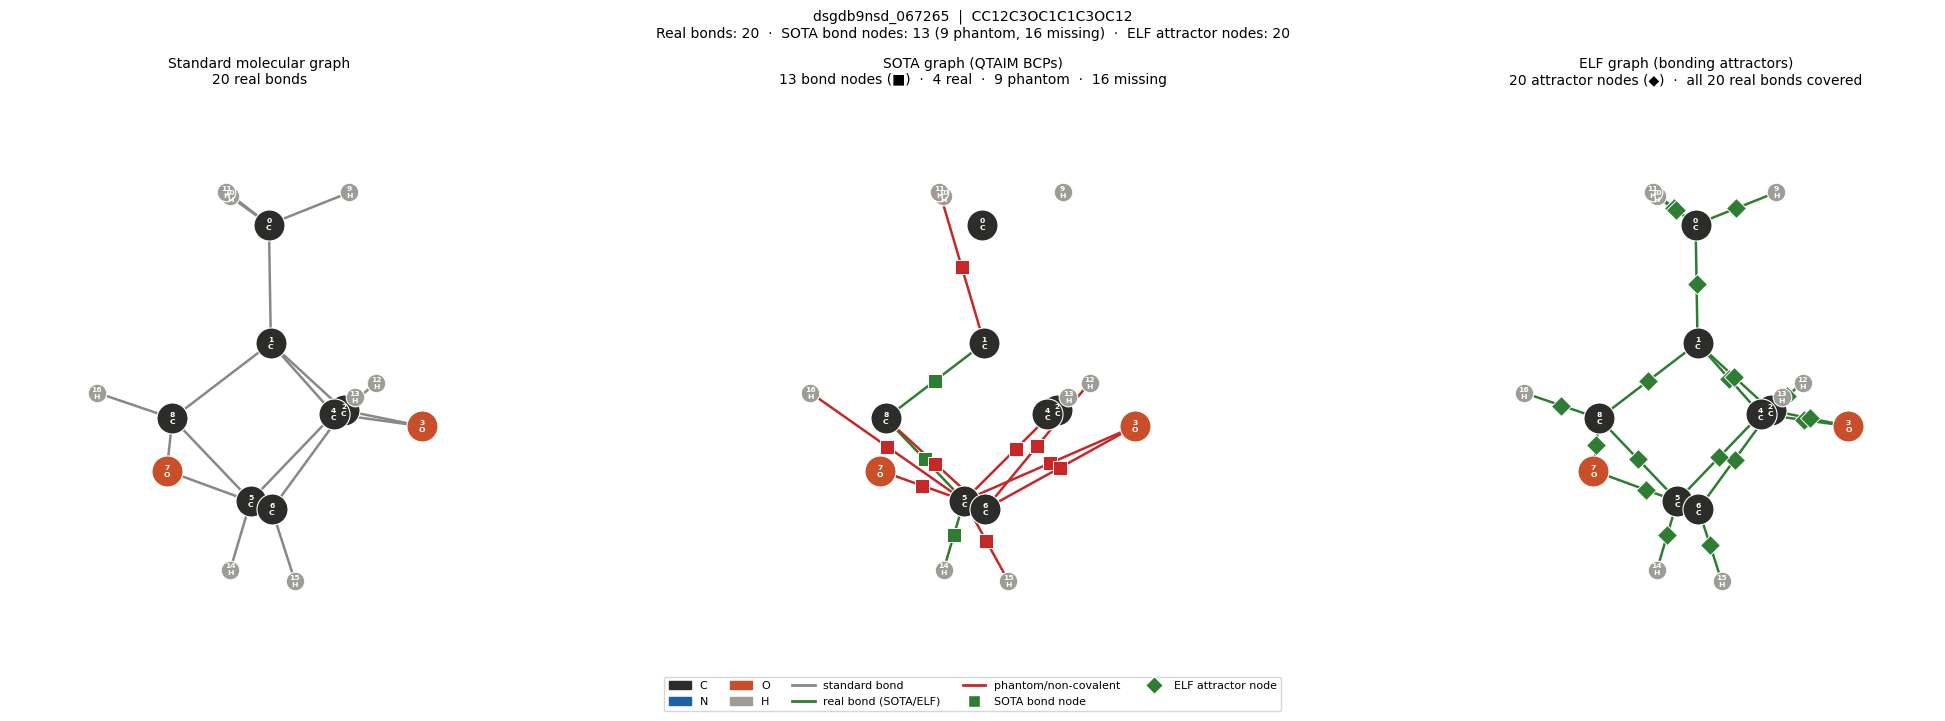

In [22]:
# ── Step 6: Three-panel comparison ────
mg_set     = set(mg_edges)
sota_bonds = sorted(bonds_col)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: standard molecular graph
draw_clean_graph(axes[0], pos, n_atoms, syms, mg_edges,
    edge_colors=["#888888"]*len(mg_edges),
    title=f"Standard molecular graph\n{len(mg_edges)} real bonds")

# Panel 2: SOTA graph
sota_extra = [((i,j),
               ((pos[i][0]+pos[j][0])/2, (pos[i][1]+pos[j][1])/2),
               "#2E7D32" if (i,j) in mg_set else "#C62828", "s", 10)
              for i,j in sota_bonds]
draw_clean_graph(axes[1], pos, n_atoms, syms, sota_bonds,
    edge_colors=["#2E7D32" if e in mg_set else "#C62828" for e in sota_bonds],
    extra_nodes=sota_extra,
    title=f"SOTA graph (QTAIM BCPs)\n"
          f"{len(sota_bonds)} bond nodes (■)  ·  "
          f"{len([e for e in sota_bonds if e in mg_set])} real  ·  "
          f"{len([e for e in sota_bonds if e not in mg_set])} phantom  ·  "
          f"{len([e for e in mg_edges if e not in set(sota_bonds)])} missing")

# Panel 3: ELF graph
elf_extra = [((i,j),
              ((pos[i][0]+pos[j][0])/2, (pos[i][1]+pos[j][1])/2),
              "#2E7D32" if (min(i,j),max(i,j)) in mg_set else "#C62828", "D", 10)
             for i,j in bond_attractors]
draw_clean_graph(axes[2], pos, n_atoms, syms,
    [(i,j) for i,j in bond_attractors],
    edge_colors=["#2E7D32" if (min(i,j),max(i,j)) in mg_set else "#C62828"
                 for i,j in bond_attractors],
    extra_nodes=elf_extra,
    title=f"ELF graph (bonding attractors)\n"
          f"{len(bond_attractors)} attractor nodes (◆)  ·  "
          f"all {len([e for e in bond_attractors if (min(e[0],e[1]),max(e[0],e[1])) in mg_set])} real bonds covered")

import matplotlib.patches as mpatches; from matplotlib.lines import Line2D
leg = [mpatches.Patch(color=ATOM_COLOR["C"],label="C"),
       mpatches.Patch(color=ATOM_COLOR["N"],label="N"),
       mpatches.Patch(color=ATOM_COLOR["O"],label="O"),
       mpatches.Patch(color=ATOM_COLOR["H"],label="H"),
       Line2D([0],[0],color="#888888",lw=2,label="standard bond"),
       Line2D([0],[0],color="#2E7D32",lw=2,label="real bond (SOTA/ELF)"),
       Line2D([0],[0],color="#C62828",lw=2,label="phantom/non-covalent"),
       Line2D([0],[0],marker="s",color="w",markerfacecolor="#2E7D32",ms=9,label="SOTA bond node"),
       Line2D([0],[0],marker="D",color="w",markerfacecolor="#2E7D32",ms=9,label="ELF attractor node")]
fig.legend(handles=leg, loc="lower center", ncol=5, fontsize=8, bbox_to_anchor=(0.5,-0.03))
fig.suptitle(
    f"{MOL_ID}  |  {smiles}\n"
    f"Real bonds: {len(mg_edges)}  ·  "
    f"SOTA bond nodes: {len(sota_bonds)} ({len([e for e in sota_bonds if e not in mg_set])} phantom, "
    f"{len([e for e in mg_edges if e not in set(sota_bonds)])} missing)  ·  "
    f"ELF attractor nodes: {len(bond_attractors)}",
    fontsize=10)
plt.tight_layout(); plt.show()
